In [2]:
import torch
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from transformer_lens import HookedTransformer
from tqdm import tqdm
import os
from pathlib import Path
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import csv


/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` state

In [3]:
from huggingface_hub import login
login(token="")

In [4]:
model = HookedTransformer.from_pretrained(
    "meta-llama/Llama-3.1-8B-Instruct",
    device="cuda",
    torch_dtype=torch.float16 
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:45<00:00, 11.38s/it]


Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer


# Load Data

In [5]:
random.seed(42)

Load Code Dataset

In [6]:
# load original problems
ds = load_dataset('newfacade/LeetCodeDataset', trust_remote_code=True)
hard_problems = [example for example in ds['train'] if example['difficulty'] == 'Hard']
print(f'Number of hard problems: {len(hard_problems)}')
problems = [(p['question_id'], p['problem_description'].split('\n\xa0')[0].replace('\xa0', " ")) for p in hard_problems 
            if len(p['problem_description'].split('\n\xa0')[0].split('.')) >= 5]
print(f'Number of hard problems with at least 5 sentences: {len(problems)}')

# load ambiguous parts
dir_path = "leetcode/unclear_portion"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())

Number of hard problems: 606
Number of hard problems with at least 5 sentences: 501


501it [00:04, 104.17it/s]


Load Math Dataset

In [7]:
dataset = []
for category in ['algebra', 'counting_and_probability', 'number_theory', 'geometry', 'intermediate_algebra', 'precalculus']:
    ds = load_dataset("EleutherAI/hendrycks_math", category)
    for item in ds['train']:
        dataset.append(item['problem'])
    for item in ds['test']:
        dataset.append(item['problem'])
print(f"Total problems in dataset: {len(dataset)}")
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4 and ('\n' not in p):
        filtered.append(p)

problems += [(i+10000, p) for i, p in enumerate(filtered)]

print(f"Number of filtered problems: {len(problems)}")

# load ambiguous parts
dir_path = "math"

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n+10000] = list(data.items())

Total problems in dataset: 10424
Number of filtered problems: 858


357it [00:03, 103.74it/s]


Load Writing Dataset

In [8]:
from collections import deque
dataset = []
cur_stems = deque([""]*5)
ds = load_dataset("PromptTensor/prompttensor-promptbank")
for item in tqdm(ds['train']):
    if item['intent'] in ['planning', 'generation']:
        if item['prompt_text'][:15] not in cur_stems:
            dataset.append(item['prompt_text'])
            cur_stems.append(item['prompt_text'][:15])
            cur_stems.popleft()
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4:
        filtered.append(p)

problems += [(i+20000, p) for i, p in enumerate(filtered)]

# load ambiguous parts
dir_path = "writing"

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n+20000] = list(data.items())


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7040/7040 [00:00<00:00, 20704.06it/s]
385it [00:02, 133.55it/s]


In [9]:
for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]

Number of problems: 1243
Combined dataset prepared with 2465 total questions.
Final dataset prepared with 1243 total questions.
Number of ambiguous questions: 643
Number of clear questions: 600


# Generate Activations

In [10]:
activations = {layer: [] for layer in range(model.cfg.n_layers)}
attn_activations = {layer: [] for layer in range(model.cfg.n_layers)}
    
for prompt in tqdm(formatted_questions, desc="Processing prompts"):
    # Tokenize the prompt
    tokens = model.to_tokens(prompt, prepend_bos=False)
    
    # Define the hooks to capture MLP post-activations
    hook_points = [f"blocks.{layer}.hook_resid_post" for layer in range(model.cfg.n_layers)]
    attn_points = [f"blocks.{layer}.attn.hook_z" for layer in range(model.cfg.n_layers)]
    
    # Run the model and cache the activations
    _, cache = model.run_with_cache(tokens, names_filter=lambda name: name in hook_points + attn_points)
    
    # For each layer, store the activation of the LAST token
    for layer in range(model.cfg.n_layers):
        # Shape of cache[hook_point] is (batch, seq_len, d_mlp)
        # We take the activation of the last token [-1] as the sequence representation
        last_token_activation = cache[hook_points[layer]][0, :, :].mean(dim=0).detach().cpu().numpy()
        activations[layer].append(last_token_activation)
        attn_activations[layer].append(cache[attn_points[layer]].detach().cpu().numpy())
        
# Convert lists of activations to numpy arrays
for layer in range(model.cfg.n_layers):
    activations[layer] = np.array(activations[layer])

Processing prompts: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 1243/1243 [02:01<00:00, 10.27it/s]


In [11]:
random_state = 1     # 10 writing, 0 coding, 42 math
y = np.array(labels)


In [12]:
probe_accuracies = {}
probe_weights_by_layer = {}

for layer in tqdm(range(len(activations)), desc="Training Probes"):
    X = activations[layer]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )

    # Train a logistic regression probe
    probe = LogisticRegression(max_iter=5000, fit_intercept=False)
    probe.fit(X_train, y_train)
    
    # Evaluate the probe
    accuracy = probe.score(X_test, y_test)
    probe_accuracies[layer] = accuracy
    probe_weights_by_layer[layer] = probe.coef_

Training Probes:   0%|                                                                                                               | 0/32 [00:00<?, ?it/s]

Training Probes: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:42<00:00,  1.32s/it]


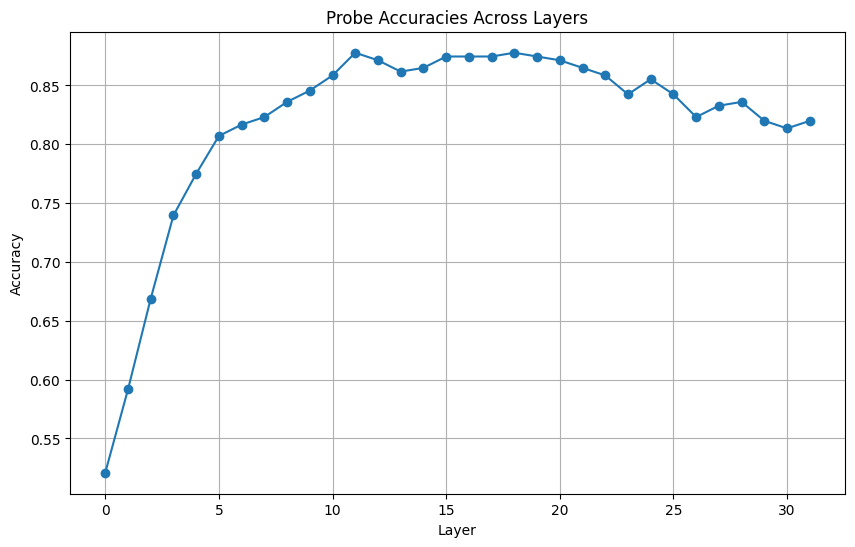

In [12]:
# graph the probe accuracies

plt.figure(figsize=(10, 6))
plt.plot(list(probe_accuracies.keys()), list(probe_accuracies.values()), marker='o')
plt.title('Probe Accuracies Across Layers')
plt.xlabel('Layer')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [13]:
# get test sample indices
idxs = np.arange(len(labels))

train_idxs, test_idxs, _, _ = train_test_split(
    idxs, y, test_size=0.25, stratify=y, random_state=random_state
)

In [61]:
y = np.array(labels)
X = activations[15]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Train a logistic regression probe
probe = LogisticRegression(max_iter=1000, fit_intercept=False)
probe.fit(X_train, y_train)

# Evaluate the probe
accuracy = probe.score(X_test, y_test)
accuracy

0.8777777777777778

# Define attribution methods + evals

In [13]:
def get_ambiguity_attribution(model, prompt, layer, probe_weights, verbose=True, return_probe_score=False):
    """
    Performs gradient attribution to find which tokens contribute
    to the sparse probe's ambiguity score.
    """
    # 1. Clear any existing gradients
    model.zero_grad()

    # 2. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    
    # 3. Manually create the token embeddings
    token_embeds = model.embed(tokens).to(torch.float16)
    token_embeds.requires_grad_(True)
    
    # Tell PyTorch to save the gradient for this non-leaf tensor
    token_embeds.retain_grad()
    # -----------------------
    
    # 4. Create a dictionary to store our (non-detached) activation
    hook_storage = {}

    # 5. Define the hook function
    def cache_hook(activation_tensor, hook):
        # Store the tensor itself, which is still in the graph
        hook_storage[hook.name] = activation_tensor
        return activation_tensor # Pass it through unchanged

    # 6. Run the model using the .hooks() context manager
    hook_name = f"blocks.{layer}.hook_resid_post"
    with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
        # Run a standard forward pass.
        _ = model(token_embeds, start_at_layer=0) 

    # 7. Get AEN activations from our storage
    aen_activations = hook_storage[hook_name][0, :, :].mean(dim=0)
        
    # 10. Calculate probe score 'S'
    S = torch.dot(aen_activations, probe_weights)

    if verbose:
        print(f"Probe score S: {S.item()}")
    
    # 11. Backpropagate
    S.backward()
    
    # 12. Get the gradients
    grads = token_embeds.grad[0] # Shape (seq_len, d_model)
    
    # 13. Calculate attribution score (Grad x Input)
    attribution_scores = torch.sum(grads * token_embeds[0], dim=1).detach().cpu().numpy()
    
    # 14. Get tokens for visualization
    str_tokens = model.to_str_tokens(tokens)
    
    if return_probe_score:
        return str_tokens, attribution_scores, S.item()
    
    return str_tokens, attribution_scores

In [14]:
def get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, verbose=True, baseline=None):
    model.zero_grad()

    # 1. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    
    token_embeds = model.embed(tokens).to(torch.float16).detach()
    
    # make the baseline the pad token id
    pad_token_id = model.tokenizer.pad_token_id

    if baseline is not None:
        baseline = baseline.unsqueeze(0).expand_as(token_embeds)
    else:
        baseline = model.embed(pad_token_id * torch.ones_like(tokens)).to(torch.float16).detach()

    total_grads = torch.zeros_like(token_embeds)

    alphas = torch.linspace(1/steps, 1, steps, device=token_embeds.device)

    hook_name = f"blocks.{layer}.hook_resid_post"

    for alpha in alphas:
        model.zero_grad()

        # 4. Interpolate embeddings
        scaled_embeds = baseline + alpha * (token_embeds - baseline)
        scaled_embeds.requires_grad_(True)
        scaled_embeds.retain_grad()

        hook_storage = {}

        # 5. Hook
        def cache_hook(activation_tensor, hook):
            hook_storage[hook.name] = activation_tensor
            return activation_tensor

        with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
            _ = model(scaled_embeds, start_at_layer=0)

        # 6. Probe score
        # aen_activations = hook_storage[hook_name][0, -1, :]
        aen_activations = hook_storage[hook_name][0, :, :].mean(dim=0)
        S = torch.dot(aen_activations, probe_weights)

        # 7. Backprop
        S.backward()

        # 8. Accumulate gradients
        total_grads += scaled_embeds.grad

    if verbose:
        print("Probe Logit:" + str(S.item()))

    # 9. Average gradients
    avg_grads = total_grads / steps

    # 10. Integrated gradients
    ig = (token_embeds - baseline) * avg_grads

    # 11. Reduce over embedding dim → per-token score
    attribution_scores = ig[0].sum(dim=1).detach().cpu().numpy()

    str_tokens = model.to_str_tokens(tokens)

    return str_tokens, attribution_scores

In [15]:
def get_direct_attribution(model, prompt, layer, probe_weights, verbose=True):
    """
    Performs gradient attribution to find which tokens contribute
    to the sparse probe's ambiguity score.
    """
    # 1. Clear any existing gradients
    model.zero_grad()

    # 2. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    
    # 3. Manually create the token embeddings
    token_embeds = model.embed(tokens).to(torch.float16)
    token_embeds.requires_grad_(True)
    
    # Tell PyTorch to save the gradient for this non-leaf tensor
    token_embeds.retain_grad()
    # -----------------------
    
    # 4. Create a dictionary to store our (non-detached) activation
    hook_storage = {}

    # 5. Define the hook function
    def cache_hook(activation_tensor, hook):
        # Store the tensor itself, which is still in the graph
        hook_storage[hook.name] = activation_tensor
        return activation_tensor # Pass it through unchanged

    # 6. Run the model using the .hooks() context manager
    hook_name = f"blocks.{layer}.hook_resid_post"
    with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
        # Run a standard forward pass.
        _ = model(token_embeds, start_at_layer=0) 

    # 7. Get AEN activations from our storage
    aen_activations = hook_storage[hook_name][0, :, :] #shape (seq_len, d_mlp)

    # probe_weights shape is (1, d_mlp) since it's a binary classification task with no intercept
    # dot product of probe weights with each token's activation
    attribution_scores = torch.matmul(aen_activations, probe_weights.t()).squeeze().detach().cpu().numpy() # shape (seq_len,)
    
    str_tokens = model.to_str_tokens(tokens)
    
    return str_tokens, attribution_scores

In [14]:
def get_ambiguity_prig_ig(model, prompt, layer, attribution_layer, probe_weights, steps=20, verbose=True, baseline=None):
    model.zero_grad()

    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")

    # -------------------------------
    # 1. Get residual stream at attribution_layer (l0)
    # -------------------------------
    hook_l0 = f"blocks.{attribution_layer}.hook_resid_post"
    hook_storage = {}

    def cache_l0(activation, hook):
        hook_storage[hook.name] = activation.detach()
        return activation

    with model.hooks(fwd_hooks=[(hook_l0, cache_l0)]):
        _ = model(tokens)

    resid_l0 = hook_storage[hook_l0]  # shape: (1, seq, d_model)
    resid_l0 = resid_l0.detach().requires_grad_(True)
    resid_l0.retain_grad()

    # -------------------------------
    # 2. Baseline in residual space
    # -------------------------------
    if baseline is None:
        baseline = torch.zeros_like(resid_l0)

    total_grads = torch.zeros_like(resid_l0)

    alphas = torch.linspace(1/steps, 1, steps, device=resid_l0.device)

    hook_probe = f"blocks.{layer}.hook_resid_post"

    # -------------------------------
    # 3. IG loop in residual space
    # -------------------------------
    for alpha in alphas:
        model.zero_grad()

        scaled_resid = baseline + alpha * (resid_l0 - baseline)
        scaled_resid = scaled_resid.detach().requires_grad_(True)
        scaled_resid.retain_grad()

        hook_storage = {}

        def cache_probe(activation, hook):
            hook_storage[hook.name] = activation
            return activation

        with model.hooks(fwd_hooks=[(hook_probe, cache_probe)]):
            _ = model(
                scaled_resid,
                start_at_layer=attribution_layer
            )

        # -------------------------------
        # 4. Probe score at layer l*
        # -------------------------------
        h_probe = hook_storage[hook_probe][0]  # (seq, d_model)

        # Same aggregation as before
        S = torch.dot(h_probe.mean(dim=0), probe_weights)

        # -------------------------------
        # 5. Backprop ONLY to resid_l0
        # -------------------------------
        S.backward()

        total_grads += scaled_resid.grad.detach()

    # -------------------------------
    # 6. Integrated gradients in residual space
    # -------------------------------
    avg_grads = total_grads / steps
    ig = (resid_l0 - baseline) * avg_grads

    # -------------------------------
    # 7. Reduce to per-token attribution
    # -------------------------------
    attribution_scores = ig[0].sum(dim=1).detach().cpu().numpy()
    str_tokens = model.to_str_tokens(tokens)

    return str_tokens, attribution_scores

In [14]:
def plot_heatmap(tokens, scores, title="Ambiguity Attribution Heatmap", mask=None, normalize=True):
    """Plots a 1D heatmap of token attributions.
    Args:
        tokens: List of token strings
        scores: List of attribution scores (same length as tokens)
        title: Title for the plot
        mask: Optional binary mask to highlight certain tokens (e.g., ground-truth ambiguous tokens)
    """
    
    # Normalize scores from 0 to 1 for easier coloring
    scores_norm = scores
    if normalize:
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())

    fig, ax = plt.subplots(figsize=(15, 2))   # ← define ax

    sns.heatmap(
        [scores_norm],
        xticklabels=tokens,
        yticklabels=False,
        cmap="Reds",
        annot=[[f"{s:.2f}" for s in scores]],
        fmt="",
        cbar=False,
        ax=ax                                  # ← pass ax
    )

    ax.set_title(title, fontsize=16)
    ax.set_xticklabels(tokens, rotation=45, ha="right")


    if mask is not None:
        mask = np.asarray(mask).astype(bool)
        for tick, m in zip(ax.get_xticklabels(), mask):
            if m:
                tick.set_color("blue")     # change color here
    # plt.tight_layout()
    plt.show()

In [15]:
# generate baseline token from average over all tokens from corpus
baseline_token = torch.zeros(model.cfg.d_model, device="cuda", dtype=torch.float16)
total_tokens = 0

for prompt in questions:
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    embeds = model.embed(tokens)[0]
    
    baseline_token += embeds.sum(dim=0).detach()
    total_tokens += embeds.shape[0]

baseline_token /= total_tokens

In [15]:
def generate_mask(pid, pdesc):
    if pid not in unclear_sentences:
        return None
    
    clr, unclr = unclear_sentences[pid][0]
    new_problem = format_question(pdesc.replace(clr, unclr))
    
    # 1. Find the character start/end of the 'unclr' string in the new text
    char_start = new_problem.find(unclr)
    char_end = char_start + len(unclr)
    
    # 2. Tokenize the full sentence
    # Note: Use return_offsets_mapping to see which chars belong to which tokens
    tokens_dict = model.tokenizer(
        new_problem, 
        return_offsets_mapping=True, 
        return_tensors="pt",
        add_special_tokens=False
    )
    
    tokenized = tokens_dict['input_ids'][0]
    offsets = tokens_dict['offset_mapping'][0] # List of (char_start, char_end) for each token
    
    # 3. Create the mask
    mask = torch.zeros_like(tokenized)
    for i, (start, end) in enumerate(offsets):
        # Check if the token overlaps with our target character range
        # We check if the token's range is within the unclr range
        # if start >= char_start and end <= char_end and start != end:
        #     mask[i] = 1
        if not (end <= char_start or start >= char_end):
            mask[i] = 1

    # apply the mask to tokenized input ids to get the unclr portion's token ids
    # unclr_token_ids = tokenized[mask == 1]
    # decoded_unclr = model.tokenizer.batch_decode(unclr_token_ids)
            
    return (new_problem, unclr, mask)

In [27]:
def generate_mask_clear(pid, pdesc):
    if pid not in unclear_sentences:
        return None
    
    clr, unclr = unclear_sentences[pid][0]
    problem = format_question(pdesc)
    
    # 1. Find the character start/end of the 'clr' string in the new text
    char_start = problem.find(clr)
    char_end = char_start + len(clr)
    
    # 2. Tokenize the full sentence
    # Note: Use return_offsets_mapping to see which chars belong to which tokens
    tokens_dict = model.tokenizer(
        problem, 
        return_offsets_mapping=True, 
        return_tensors="pt",
        add_special_tokens=False
    )
    
    tokenized = tokens_dict['input_ids'][0]
    offsets = tokens_dict['offset_mapping'][0] # List of (char_start, char_end) for each token
    
    # 3. Create the mask
    mask = torch.zeros_like(tokenized)
    for i, (start, end) in enumerate(offsets):
        # Check if the token overlaps with our target character range
        # We check if the token's range is within the clr range
        if start >= char_start and end <= char_end and start != end:
            mask[i] = 1

    # apply the mask to tokenized input ids to get the clr portion's token ids
    # clr_token_ids = tokenized[mask == 1]
    # decoded_clr = model.tokenizer.batch_decode(clr_token_ids)
            
    return (problem, clr, mask)

In [45]:
pairs = []
for pid, pdesc in problems:
    res = generate_mask(pid, pdesc)
    if res is not None:        
        pairs.append(res)

In [17]:
from sklearn.metrics import roc_auc_score, auc
from sklearn_prg.metrics import precision_recall_gain_curve, average_precision_recall_gain

def span_auroc(scores, mask):
    scores = np.asarray(scores)
    mask = np.asarray(mask).astype(int)

    return roc_auc_score(mask, scores)

def span_auprg(scores, mask):
    scores = np.asarray(scores)
    mask = np.asarray(mask).astype(int)
    pg, rg = precision_recall_gain_curve(mask, scores)
    return auc(rg, pg)

In [18]:
# smooth attribution scores with a Gaussian kernel
from scipy.ndimage import gaussian_filter1d
def gaussian_smooth(attribution, sigma=3):
    if sigma == 0:
        return np.array(attribution)
    attribution = np.array(attribution)
    return gaussian_filter1d(attribution, sigma=sigma)

In [ ]:
# for end in range(8,21,2):
#     for start in range(6,17,2):
#         if start > end:
#             continue
#         layer=end
#         probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
#         mask = None
#         prompt, _, mask = pairs[7]
#         # str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, baseline=baseline_token)
#         # str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
#         str_tokens, scores = get_ambiguity_prig_ig(model, prompt, layer, attribution_layer=start, probe_weights=probe_weights, steps=50, baseline=None)
#         # str_tokens, scores = str_tokens[10:-5], gaussian_smooth(scores[10:-5].astype(np.float32), sigma=3)
#         str_tokens, scores = str_tokens[10:-5], scores[10:-5].astype(np.float32)
#         mask = mask[10:-5] if mask is not None else None
#         plot_heatmap(str_tokens, scores, title=None, normalize=False, mask=mask)
#         print(start, end)
#         print("Span AUROC:", span_auroc(scores, mask))
#         print("Span AUROC w smoothing 1.5:", span_auroc(gaussian_smooth(scores, sigma=1.5), mask))
#         print("Span AUROC w smoothing 3:", span_auroc(gaussian_smooth(scores, sigma=3), mask))

In [ ]:
# attributions = {}
# for layer in range(5,model.cfg.n_layers):
#     print(f"Layer {layer} probe accuracy: {probe_accuracies[layer]:.4f}")
#     probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
#     # prompt = format_question("""That question is so ambiguous, I have no idea what it means""")
#     mask = None
#     prompt, _, mask = pairs[3]
#     # str_tokens, scores = get_circuit_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, top_k=10)
#     # str_tokens, scores = get_ambiguity_attribution(model, prompt, layer, probe_weights)
#     # str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, baseline=baseline_token)
#     str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
#     print(span_auroc(scores[10:-5], mask[10:-5]))
#     # str_tokens, scores = get_ambiguity_attribution_aggregated_ig(model, prompt, layer, probe_weights, steps=30, baseline=baseline_token)
#     str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, baseline=baseline_token)
#     str_tokens, scores = str_tokens[10:-5], scores[10:-5]
#     mask = mask[10:-5] if mask is not None else None
#     plot_heatmap(str_tokens, scores, title=None, normalize=False, mask=mask)
#     print(span_auroc(scores, mask))
#     # plot_heatmap(str_tokens, softmax(scores), title=None, normalize=False, mask=mask)
#     # print(span_auroc(softmax(scores), mask))
#     attributions[layer] = scores

In [ ]:
layer=16
probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)

prompt, _, mask = pairs[3]
# str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, baseline=None)
# str_tokens, scores = get_ambiguity_attribution_new(model, prompt, layer, probe_weights)
# str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
str_tokens, scores = get_ambiguity_prig_ig(model, prompt, layer, attribution_layer=12, probe_weights=probe_weights, steps=50, baseline=None)
scores = scores.astype(np.float32)
# str_tokens, scores = str_tokens[10:-5], gaussian_smooth(scores[10:-5].astype(np.float32), sigma=3)
str_tokens, scores = str_tokens[10:-5], scores[10:-5].astype(np.float32)
mask = mask[10:-5] if mask is not None else None
plot_heatmap(str_tokens, scores, title=None, normalize=False, mask=mask)
plot_heatmap(str_tokens, gaussian_smooth(scores, sigma=1.5), title=None, normalize=False, mask=mask)
plot_heatmap(str_tokens, gaussian_smooth(scores, sigma=3), title=None, normalize=False, mask=mask)
plot_heatmap(str_tokens, gaussian_smooth(scores, sigma=5), title=None, normalize=False, mask=mask)
print("Span AUROC:", span_auroc(scores, mask))
print("Span AUROC w smoothing 1.5:", span_auroc(gaussian_smooth(scores, sigma=1.5), mask))
print("Span AUROC w smoothing 3:", span_auroc(gaussian_smooth(scores, sigma=3), mask))

# Run Attributions

In [95]:
save_dir = "combined_attributions"
probe_category = "combined"

In [ ]:
method = "prig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

options = [(12,14), (13,15), (12,16), (16,20)]
for start_layer, end_layer in options:
    results = {}
    for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
        pid, pdesc = problems[idx]
        if pid not in unclear_sentences:
            continue
        prompt, _, mask = generate_mask(pid, pdesc)
        mask = mask[10:-5]
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_prig_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[idx] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
        }
        # Save intermediate results to file after each layer
        with open(f"{cur_dir}/prig_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

  0%|                                                                                                                                  | 0/311 [00:00<?, ?it/s]

 48%|█████████████████████████████████████████████████████████▉                                                              | 150/311 [08:46<08:44,  3.26s/it]

In [23]:
with open("gold_problems.json", "r") as f:
    problems2 = json.load(f)

problems2 = [(i, p) for i, p in enumerate(problems2)]
unclear_sentences2 = {}
# load ambiguous parts
dir_path = "gold"

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences2[n] = list(data.items())


12it [00:00, 114.36it/s]


In [24]:
for pid, pdesc in problems2:
    unclear_sentences2[pid] = [
        (og, new)
        for og, new in unclear_sentences2[pid]
        if og in pdesc
    ]
print(f"Number of problems2: {len(problems2)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences2.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences2[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems2]
ambiguous = []
for pid, pdesc in problems2:
    if pid not in unclear_sentences2:
        continue
    idx = random.randint(0, len(unclear_sentences2[pid]) - 1)
    clr, unclr = unclear_sentences2[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems2]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems2:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences2 or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences2[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]

Number of problems2: 12
Combined dataset prepared with 24 total questions.
Final dataset prepared with 12 total questions.
Number of ambiguous questions: 6
Number of clear questions: 6


In [33]:
pairs = []
for pid, pdesc in problems2:
    res = generate_mask(pid, pdesc)
    if res is not None:        
        pairs.append(res)

In [26]:
save_dir = "gold_attributions"
probe_category = "combined"

In [70]:
method = "prig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

options = [(12,14), (13,15), (12,16), (16,20)]
for start_layer, end_layer in options:
    results = {}
    for pid, pdesc in tqdm(problems2):
        if pid not in unclear_sentences2:
            print("err")
            continue
        prompt, _, mask = generate_mask(pid, pdesc)
        mask = mask[10:-5]
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_prig_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[pid] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
        }
        # Save intermediate results to file after each layer
        with open(f"{cur_dir}/prig_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:44<00:00,  3.72s/it]


In [96]:
method = "gradient"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

results = {}
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    prompt, _, mask = generate_mask(pid, pdesc)
    mask = mask[10:-5]
    
    attributions = {}
    for layer in [12, 14, 16]:#range(model.cfg.n_layers):
        probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
        # str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
        str_tokens, scores = get_ambiguity_attribution(model, prompt, layer, probe_weights, verbose=False)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions[layer] = scores.tolist()
    
    results[idx] = {
        "pid": pid,
        "pdesc": pdesc,
        "tokens": str_tokens,
        "attributions": attributions,
        "mask": mask.tolist(),
    }
    # Save intermediate results to file after each layer
    with open(f"{cur_dir}/attribution_results.json", "w") as f:
        json.dump(results, f)

  0%|                                                                                                                                   | 0/311 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311/311 [02:45<00:00,  1.88it/s]


In [ ]:
method = "ig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)
results = {}
# with open(f"{save_dir}/{probe_category}/{method}/attribution_results.json", "r") as f:
#     results = json.load(f)
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    prompt, _, mask = generate_mask(pid, pdesc)
    mask = mask[10:-5]
    
    attributions = {}
    for layer in [12, 14, 16]: 
        probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, baseline=baseline_token, verbose=False)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions[layer] = scores.tolist()
    
    results[idx] = {
        "pid": pid,
        "pdesc": pdesc,
        "tokens": str_tokens,
        "attributions": attributions,
        "mask": mask.tolist(),
    }
    # Save intermediate results to file after each layer
    with open(f"{cur_dir}/attribution_results.json", "w") as f:
        json.dump(results, f)

 10%|███████████▊                                                                                                              | 30/311 [03:25<33:08,  7.08s/it]

Same runs, but with the original texts (no ambiguity)

In [31]:
pairs = []
for pid, pdesc in problems:
    res = generate_mask_clear(pid, pdesc)
    if res is not None:        
        pairs.append(res)
len(pairs)

1222

In [32]:
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    prompt, _, mask = generate_mask_clear(pid, pdesc)
    mask = mask[10:-5]
    if mask.sum() == 0:
        print("e")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311/311 [00:00<00:00, 665.56it/s]


In [33]:
save_dir = "combined_attributions"
probe_category = "combined"
method = "prig"
cur_dir = f"{save_dir}_clear/{probe_category}/{method}/"

In [34]:
f"{save_dir}_clear/{probe_category}/prig/prig_{start_layer}_{end_layer}_attribution_results.json"

'combined_attributions_clear/combined/prig/prig_13_15_attribution_results.json'

In [35]:
save_dir = "combined_attributions"
probe_category = "combined"
method = "prig"
cur_dir = f"{save_dir}_clear/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)
options = [(13,15)]
for start_layer, end_layer in options:
    results = {}
    for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
        pid, pdesc = problems[idx]
        if pid not in unclear_sentences:
            continue
        prompt, _, mask = generate_mask_clear(pid, pdesc)
        mask = mask[10:-5]
        if mask.sum() == 0:
            continue
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_prig_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[idx] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
        }
        # Save intermediate results to file after each layer
        with open(f"{cur_dir}/prig_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311/311 [13:15<00:00,  2.56s/it]


# Evaluations

In [36]:
save_dir = "combined_attributions_clear"
probe_category = "combined"

In [23]:
method = "gradient" # ig
def scoring_over_layers(save_dir, probe_category, method):
    with open(f"{save_dir}/{probe_category}/{method}/attribution_results.json", "r") as fd:
        results = json.load(fd)

    csv_file = f"{save_dir}/{probe_category}/{method}/results.csv"

    with open(csv_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["layer", "metric", "sigma", "mean", "std"])

        for sigma in [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]:
            layers = [12, 14, 16]

            auroc_by_layer = [[] for _ in range(len(layers))]
            auprg_by_layer = [[] for _ in range(len(layers))]

            for idx, data in results.items():
                mask = np.array(data["mask"])
                for i, layer in enumerate(layers):
                    attribution = np.array(data["attributions"][str(layer)])
                    attribution = gaussian_smooth(attribution, sigma=sigma)

                    auroc = span_auroc(attribution, mask)
                    auroc_by_layer[i].append(auroc)

                    p = mask.sum() / len(mask)

                    auprg = span_auprg(attribution, mask)
                    auprg_by_layer[i].append(auprg)

            auroc_by_layer = np.array(auroc_by_layer)
            auprg_by_layer = np.array(auprg_by_layer)

            auroc_means = auroc_by_layer.mean(axis=1)
            auroc_stds = auroc_by_layer.std(axis=1)


            auprg_means = auprg_by_layer.mean(axis=1)
            auprg_stds = auprg_by_layer.std(axis=1)

            for i, layer in enumerate(layers):
                writer.writerow([layer, "auroc", sigma, auroc_means[i], auroc_stds[i]])
                writer.writerow([layer, "auprg", sigma, auprg_means[i], auprg_stds[i]])

In [37]:
def prig_scoring(save_dir, probe_category):
    options = [ (12,14), (13,15), (12,16), (16,20)]
    # options = [(8,10),(8,12), (10,12), (12,14), (13,15), (12,16), (16,20),  (18,20)]
    options = [(13,15)]

    csv_file = f"{save_dir}/{probe_category}/prig/results.csv"
    with open(csv_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["start_layer", "end_layer","metric", "sigma", "mean", "std"])

        for start_layer, end_layer in options:
            with open(f"{save_dir}/{probe_category}/prig/prig_{start_layer}_{end_layer}_attribution_results.json", "r") as fd:
                results = json.load(fd)

            for sigma in [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]:
                auroc_by_option = []
                auprg_by_option = []
                for idx, data in results.items():

                    attribution = np.array(data["attributions"])
                    mask = np.array(data["mask"])
                    
                    attribution = gaussian_smooth(attribution, sigma=sigma)

                    auroc = span_auroc(attribution, mask)
                    auroc_by_option.append(auroc)

                    p = mask.sum() / len(mask)

                    auprg = span_auprg(attribution, mask)
                    auprg_by_option.append(auprg)

                auroc_by_option = np.array(auroc_by_option)
                auprg_by_option = np.array(auprg_by_option)

                auroc_mean = auroc_by_option.mean()
                auroc_std = auroc_by_option.std()


                auprg_mean = auprg_by_option.mean()
                auprg_std = auprg_by_option.std()

                writer.writerow([start_layer, end_layer, "auroc", sigma, auroc_mean, auroc_std])
                writer.writerow([start_layer, end_layer, "auprg", sigma, auprg_mean, auprg_std])

In [38]:
prig_scoring(save_dir, probe_category)

In [ ]:
scoring_over_layers(save_dir, probe_category, "ig")

In [ ]:
scoring_over_layers(save_dir, probe_category, "gradient")

In [37]:
for save_dir in ['code_attributions', 'math_attributions', 'writing_attributions']:
    for probe_category in tqdm(['code', 'math', 'writing']):
        prig_scoring(save_dir, probe_category)

100%|██████████| 3/3 [00:43<00:00, 14.37s/it]


In [34]:
for method in ["ig", "gradient"]:
    for save_dir, probe_category in [ ('writing_attributions', 'writing')]:
        scoring_over_layers(save_dir, probe_category, method)

# Visualize

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_scoring_results(save_dir, probe_category, method):
    # Load the results
    csv_file = f"{save_dir}/{probe_category}/{method}/results.csv"
    df = pd.read_csv(csv_file)

    # Set the visual style
    sns.set_theme(style="whitegrid")
    
    # We want one plot per metric (AUROC, AUPRC, AUPRG)
    metrics = df['metric'].unique()
    
    # Create a figure with subplots
    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 6), sharex=True)
    
    for i, metric in enumerate(metrics):
        # Filter data for the specific metric
        metric_df = df[df['metric'] == metric]
        
        # Plot mean score vs layer
        # 'hue' separates by sigma, 'style' adds visual distinction if desired
        sns.lineplot(
            data=metric_df,
            x='layer',
            y='mean',
            hue='sigma',
            marker='o',
            palette='viridis',
            ax=axes[i]
        )
        axes[i].set_ylim(0, 1)
        
        # Optional: Add error bars using the 'std' column from your CSV
        axes[i].errorbar(
            metric_df['layer'], 
            metric_df['mean'], 
            yerr=metric_df['std'], 
            fmt='none', 
            alpha=0.3, 
            ecolor='gray'
        )

        axes[i].set_title(f'Mean {metric.upper()} vs Layer')
        axes[i].set_ylabel('Mean Score')
        axes[i].set_xlabel('Transformer Layer')
        axes[i].set_xticks(metric_df['layer'].unique())
        
    plt.tight_layout()
    plt.show()

# plot_scoring_results("code_attributions", "code", "ig")

In [41]:
def plot_prig_results(save_dir, probe_category):
    # Load the results
    csv_file = f"{save_dir}/{probe_category}/prig/results.csv"
    df = pd.read_csv(csv_file)

    # Create a string label for the 'options' (ranges) to make the x-axis readable
    df['layer_range'] = df['start_layer'].astype(str) + "-" + df['end_layer'].astype(str)
    
    # Ensure the order follows the sequence in your options list, not alphabetical
    range_order = df[['start_layer', 'end_layer', 'layer_range']].drop_duplicates() \
                    .sort_values(['start_layer', 'end_layer'])['layer_range'].tolist()

    sns.set_theme(style="whitegrid")
    metrics = df['metric'].unique()
    
    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
    
    # If only one metric exists, axes might not be an array; wrap it to be safe
    if len(metrics) == 1: axes = [axes]

    for i, metric in enumerate(metrics):
        metric_df = df[df['metric'] == metric]
        
        # Using a categorical pointplot or lineplot
        sns.lineplot(
            data=metric_df,
            x='layer_range',
            y='mean',
            hue='sigma',
            marker='o',
            palette='magma', # Different palette to distinguish from previous plots
            ax=axes[i],
            sort=False # Keep the order we defined in range_order
        )
        
        # Force y-axis from 0 to 1 as requested
        axes[i].set_ylim(0, 1)
        
        axes[i].set_title(f'PRIG {metric.upper()}')
        axes[i].set_ylabel('Mean Score')
        axes[i].set_xlabel('Layer Range (Start-End)')
        
        # Rotate x-labels if they start overlapping
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Example usage:
# plot_prig_results("code_attributions", "code")

In [ ]:
for method in ["ig, gradient"]:
    for save_dir, probe_category in [('combined_attributions', 'combined')]:
        print(f"Probe: {probe_category}; Dataset evaluated on: {save_dir}")
        csv_file = f"{save_dir}/{probe_category}/{method}/results.csv"
        df = pd.read_csv(csv_file)
        # print(df.to_string(index=False))
        print("Best AUROC:")
        rocdf = df[(df['metric'] == 'auroc') & (df['sigma'].isin([3.0])) & (df['layer'] == 14)]
        print(rocdf.loc[rocdf['mean'].idxmax()].to_string())
        print("Best AUPRG:")
        prgdf = df[(df['metric'] == 'auprg') & (df['sigma'].isin([3.0]))& (df['layer'] == 14)]
        print(prgdf.loc[prgdf['mean'].idxmax()].to_string())
        print("=="*10)
        # plot_prig_results(save_dir, probe_category)

In [81]:
probe_category = "combined"
save_dir = "gold_attributions"
print(f"Probe: {probe_category}; Dataset evaluated on: {save_dir}")
csv_file = f"{save_dir}/{probe_category}/prig/results.csv"
df = pd.read_csv(csv_file)
print(df.to_string(index=False))

Probe: combined; Dataset evaluated on: gold_attributions
 start_layer  end_layer metric  sigma     mean      std
          12         14  auroc    3.0 0.894713 0.087974
          12         14  auprg    3.0 0.827707 0.209417
          13         15  auroc    3.0 0.834094 0.132298
          13         15  auprg    3.0 0.784460 0.215715
          12         16  auroc    3.0 0.879891 0.070028
          12         16  auprg    3.0 0.804974 0.162842
          16         20  auroc    3.0 0.891392 0.096884
          16         20  auprg    3.0 0.869613 0.131061


In [42]:
# probe_category = "combined"
# save_dir = "combined_attributions"
print(f"Probe: {probe_category}; Dataset evaluated on: {save_dir}")
csv_file = f"{save_dir}/{probe_category}/prig/results.csv"
df = pd.read_csv(csv_file)
# print(df.to_string(index=False))
print("Best AUROC:")
rocdf = df[(df['metric'] == 'auroc') & (df['sigma'] == 3.0)]
print(rocdf.loc[rocdf['mean'].idxmax()].to_string())
print("Best AUPRG:")
prgdf = df[(df['metric'] == 'auprg') & (df['sigma'] == 3.0)]
print(prgdf.loc[prgdf['mean'].idxmax()].to_string())
print("=="*10)

Probe: combined; Dataset evaluated on: combined_attributions_clear
Best AUROC:
start_layer          13
end_layer            15
metric            auroc
sigma               3.0
mean           0.452343
std            0.247396
Best AUPRG:
start_layer          13
end_layer            15
metric            auprg
sigma               3.0
mean           0.195189
std            0.290168


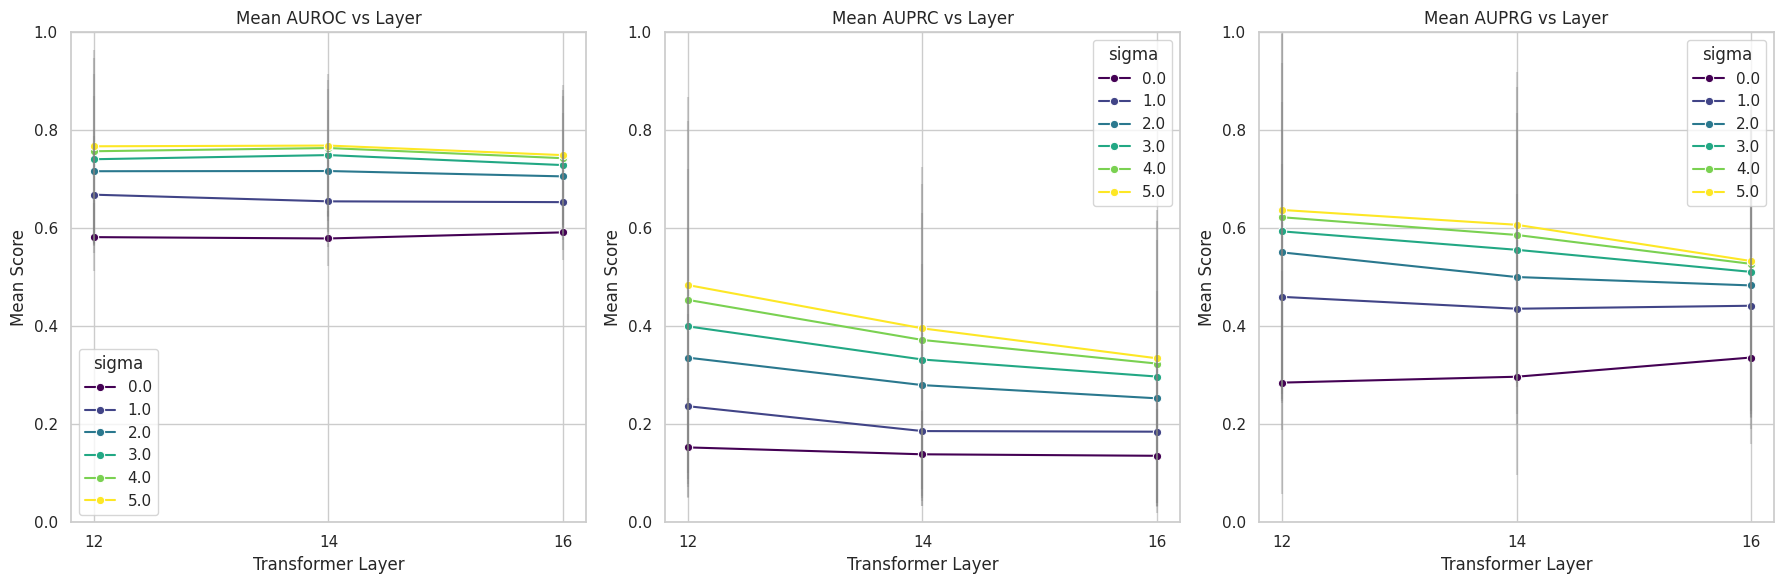

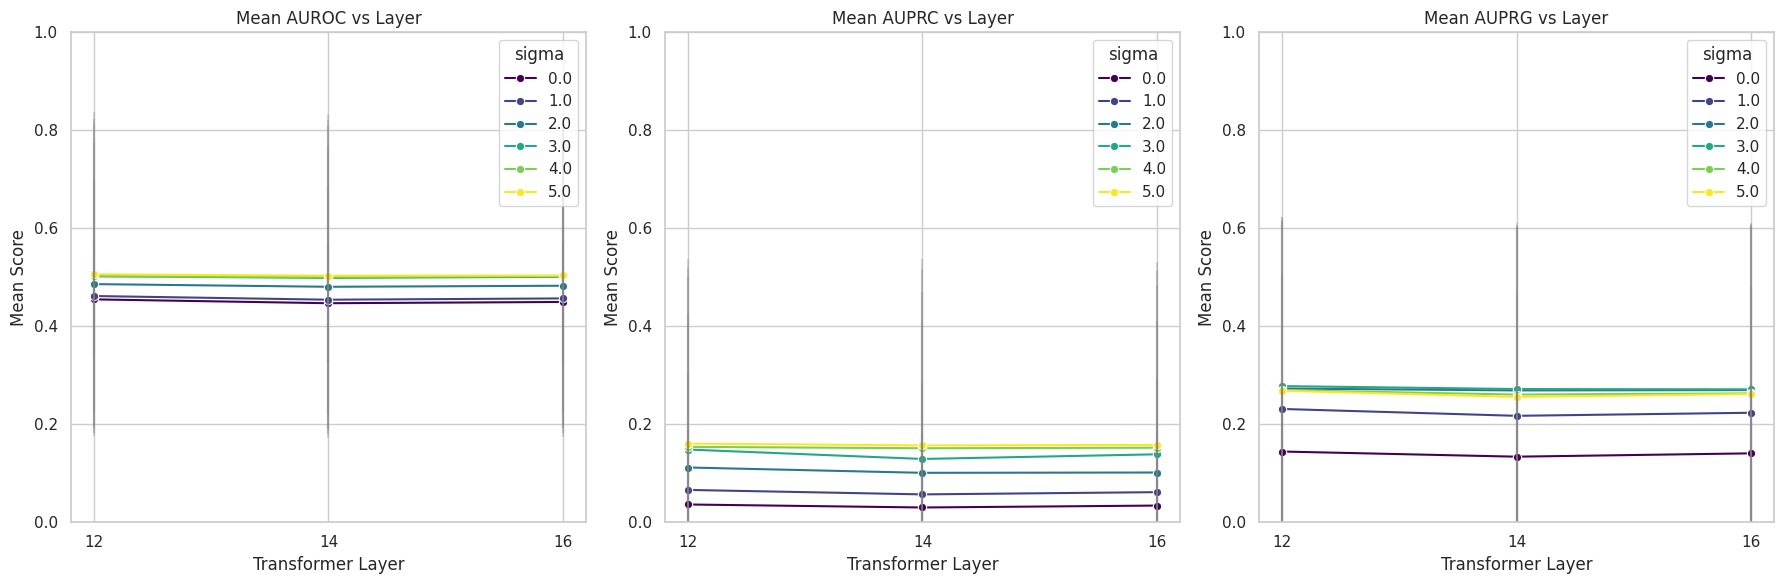

In [79]:
plot_scoring_results(save_dir, probe_category, "gradient")
plot_scoring_results(save_dir, probe_category, "ig")

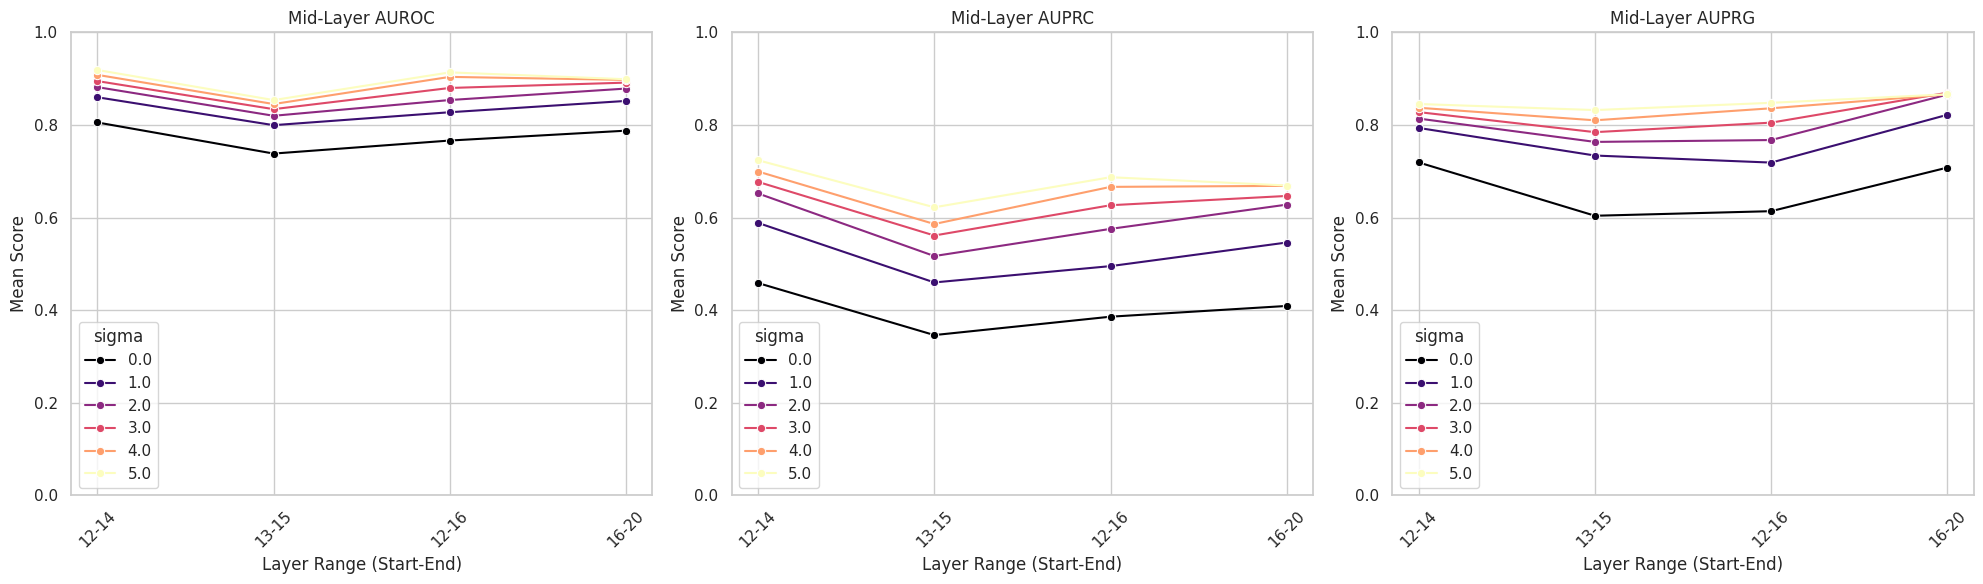

In [80]:
plot_prig_results("gold_attributions", "combined")

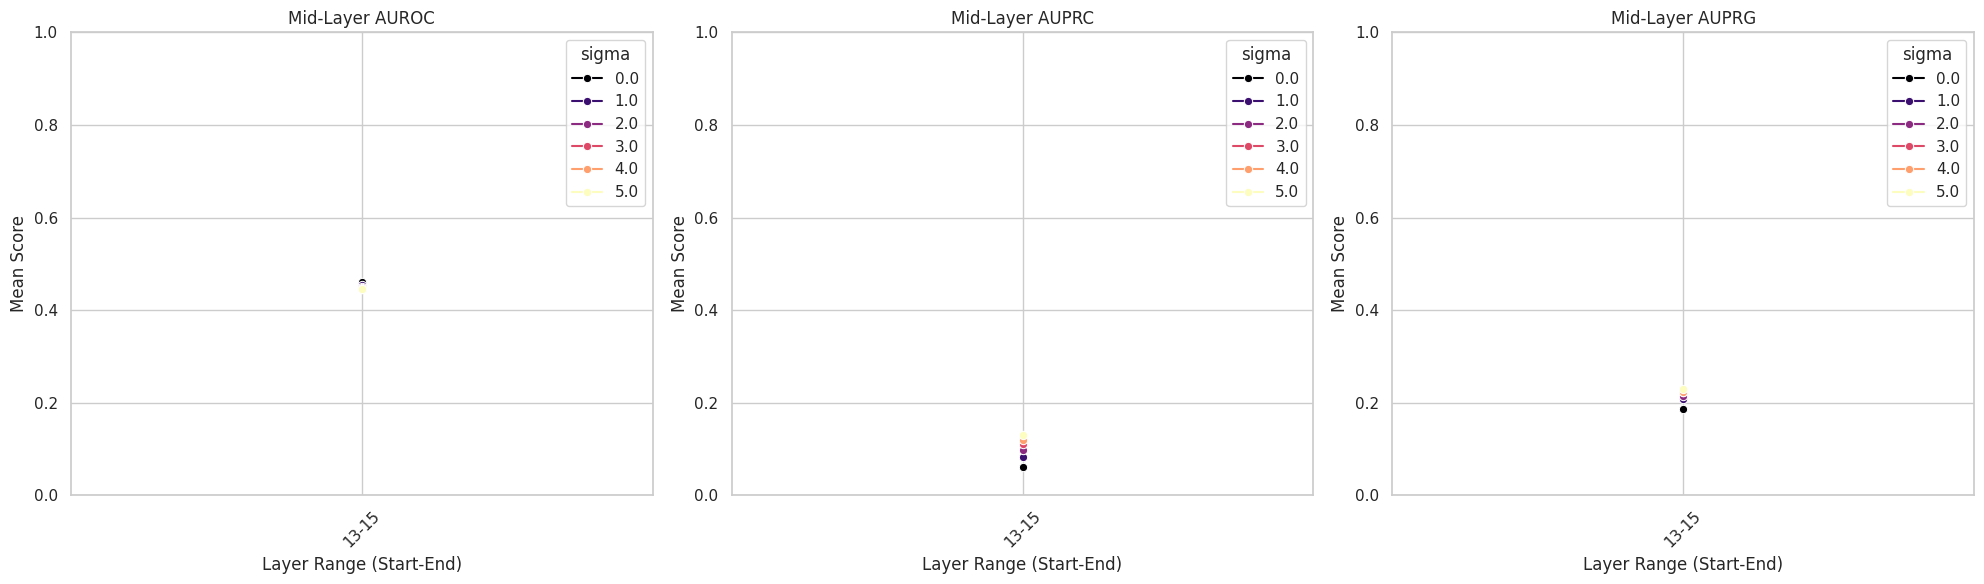

In [53]:
plot_prig_results("combined_attributions_clear", "combined")

In [44]:
probe_category = "combined"
save_dir = "combined_attributions"
print(f"Probe: {probe_category}; Dataset evaluated on: {save_dir}")
csv_file = f"{save_dir}/{probe_category}/prig/results.csv"
df = pd.read_csv(csv_file)
# print(df.to_string(index=False))
print("Best AUROC:")
rocdf = df[(df['metric'] == 'auroc') & (df['sigma'] == 3.0)]
print(rocdf.loc[rocdf['mean'].idxmax()].to_string())
print("Best AUPRG:")
prgdf = df[(df['metric'] == 'auprg') & (df['sigma'] == 3.0)]
print(prgdf.loc[prgdf['mean'].idxmax()].to_string())
print("=="*10)

Probe: combined; Dataset evaluated on: combined_attributions
Best AUROC:
start_layer          12
end_layer            14
metric            auroc
sigma               3.0
mean           0.813198
std            0.165638
Best AUPRG:
start_layer          12
end_layer            14
metric            auprg
sigma               3.0
mean           0.660633
std            0.315335


In [42]:
for save_dir in ['code_attributions', 'math_attributions', 'writing_attributions']:
    for probe_category in ['code', 'math', 'writing']:

        print(f"Probe: {probe_category}; Dataset evaluated on: {save_dir}")
        csv_file = f"{save_dir}/{probe_category}/prig/results.csv"
        df = pd.read_csv(csv_file)
        # print(df.to_string(index=False))
        print("Best AUROC:")
        rocdf = df[(df['metric'] == 'auroc') & (df['sigma'] == 3.0)]
        print(rocdf.loc[rocdf['mean'].idxmax()].to_string())
        print("Best AUPRG:")
        prgdf = df[(df['metric'] == 'auprg') & (df['sigma'] == 3.0)]
        print(prgdf.loc[prgdf['mean'].idxmax()].to_string())
        print("=="*10)
        # plot_prig_results(save_dir, probe_category)

Probe: code; Dataset evaluated on: code_attributions
Best AUROC:
start_layer          12
end_layer            16
metric            auroc
sigma               3.0
mean           0.921946
std            0.113844
Best AUPRG:
start_layer          12
end_layer            16
metric            auprg
sigma               3.0
mean           0.875888
std            0.217953
Probe: math; Dataset evaluated on: code_attributions
Best AUROC:
start_layer          16
end_layer            20
metric            auroc
sigma               3.0
mean           0.878978
std            0.133838
Best AUPRG:
start_layer          16
end_layer            20
metric            auprg
sigma               3.0
mean           0.815221
std            0.267461
Probe: writing; Dataset evaluated on: code_attributions
Best AUROC:
start_layer          13
end_layer            15
metric            auroc
sigma               3.0
mean           0.827528
std            0.162855
Best AUPRG:
start_layer          13
end_layer            1

code_attributions code


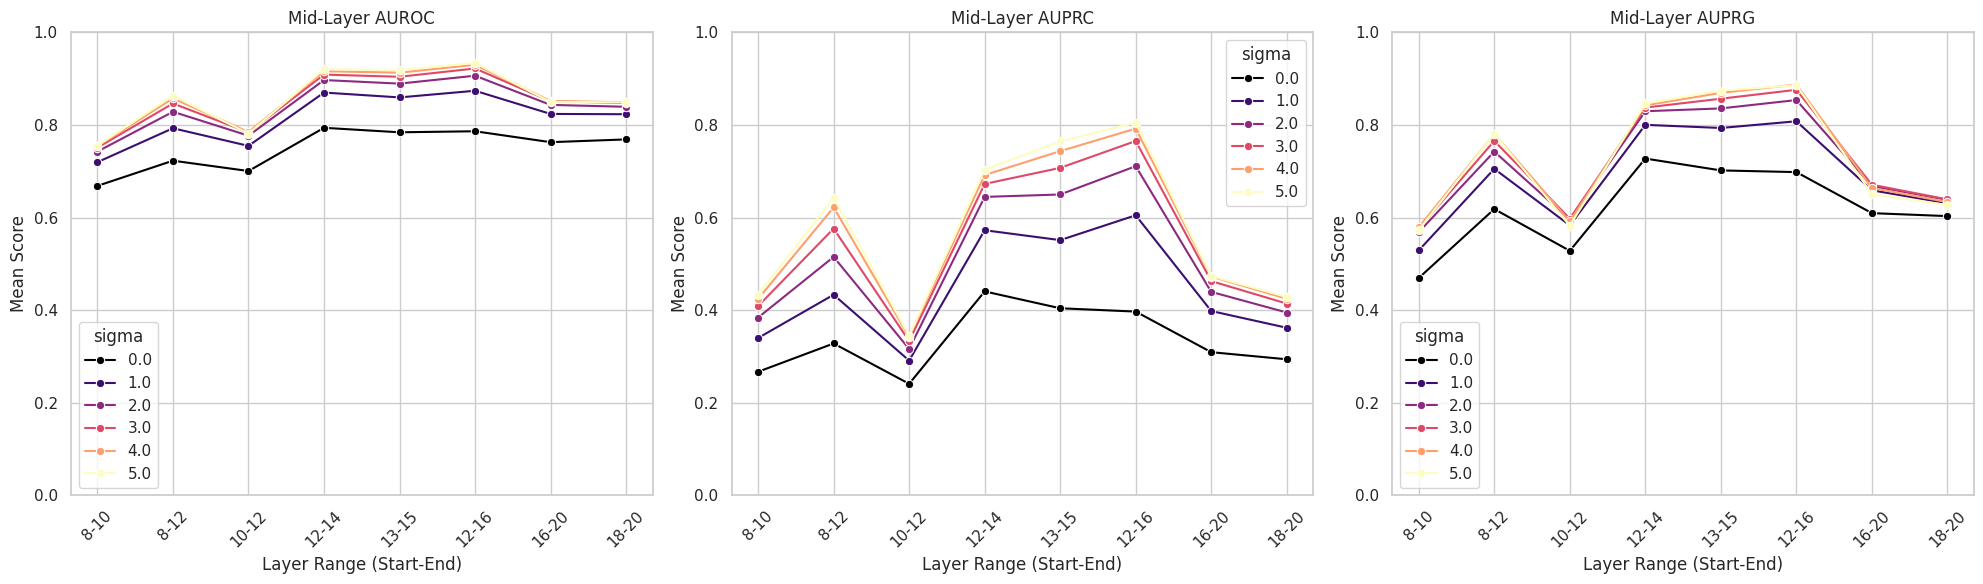

math_attributions code


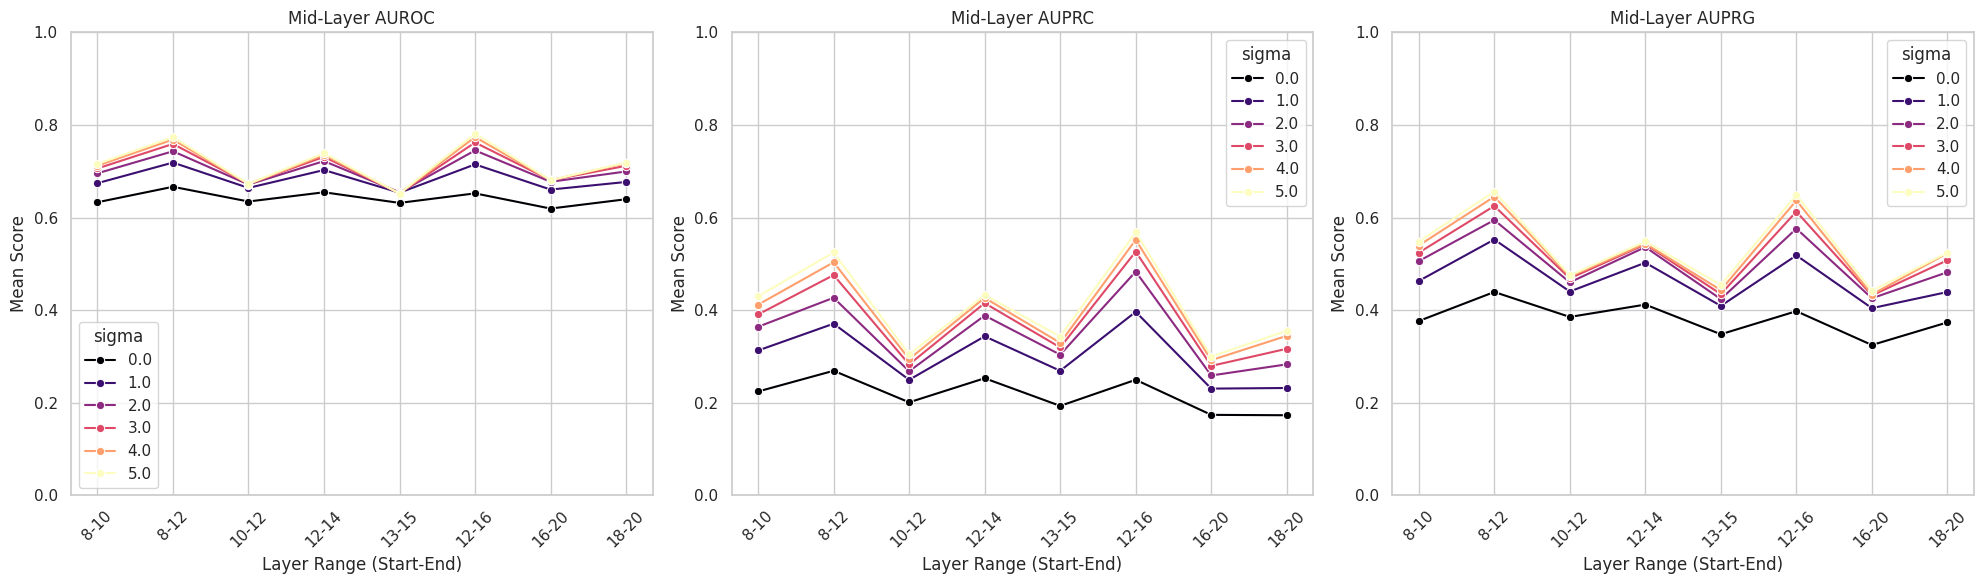

writing_attributions code


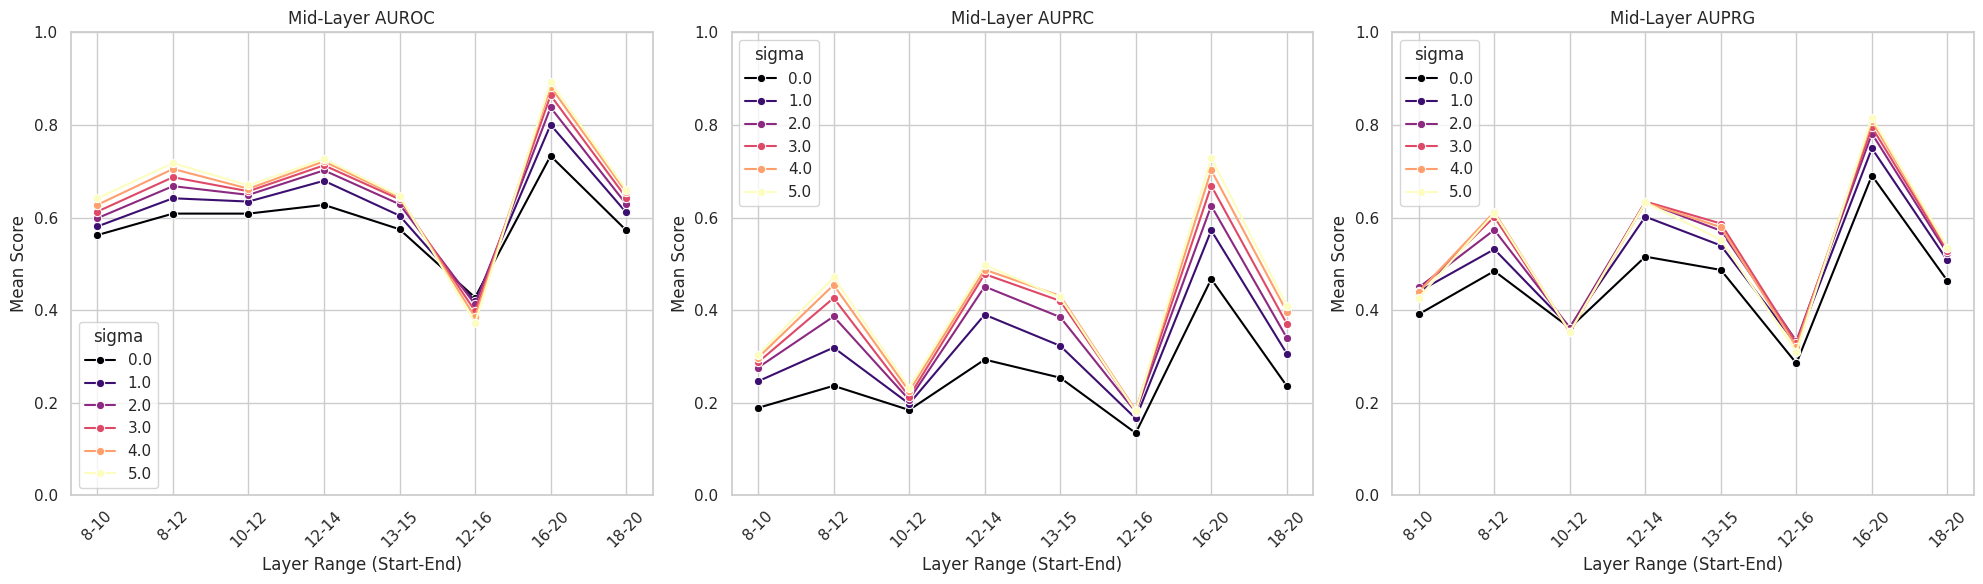

code_attributions math


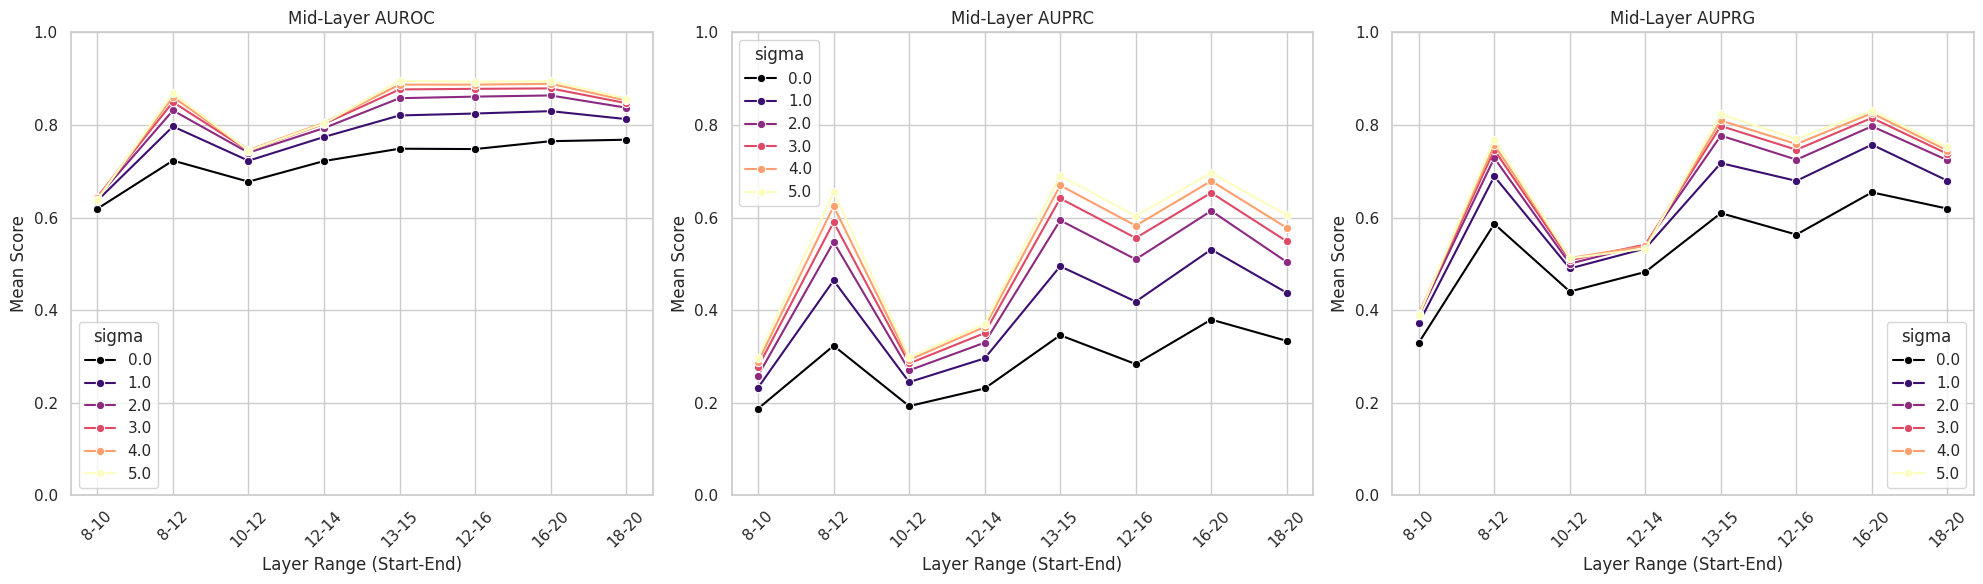

math_attributions math


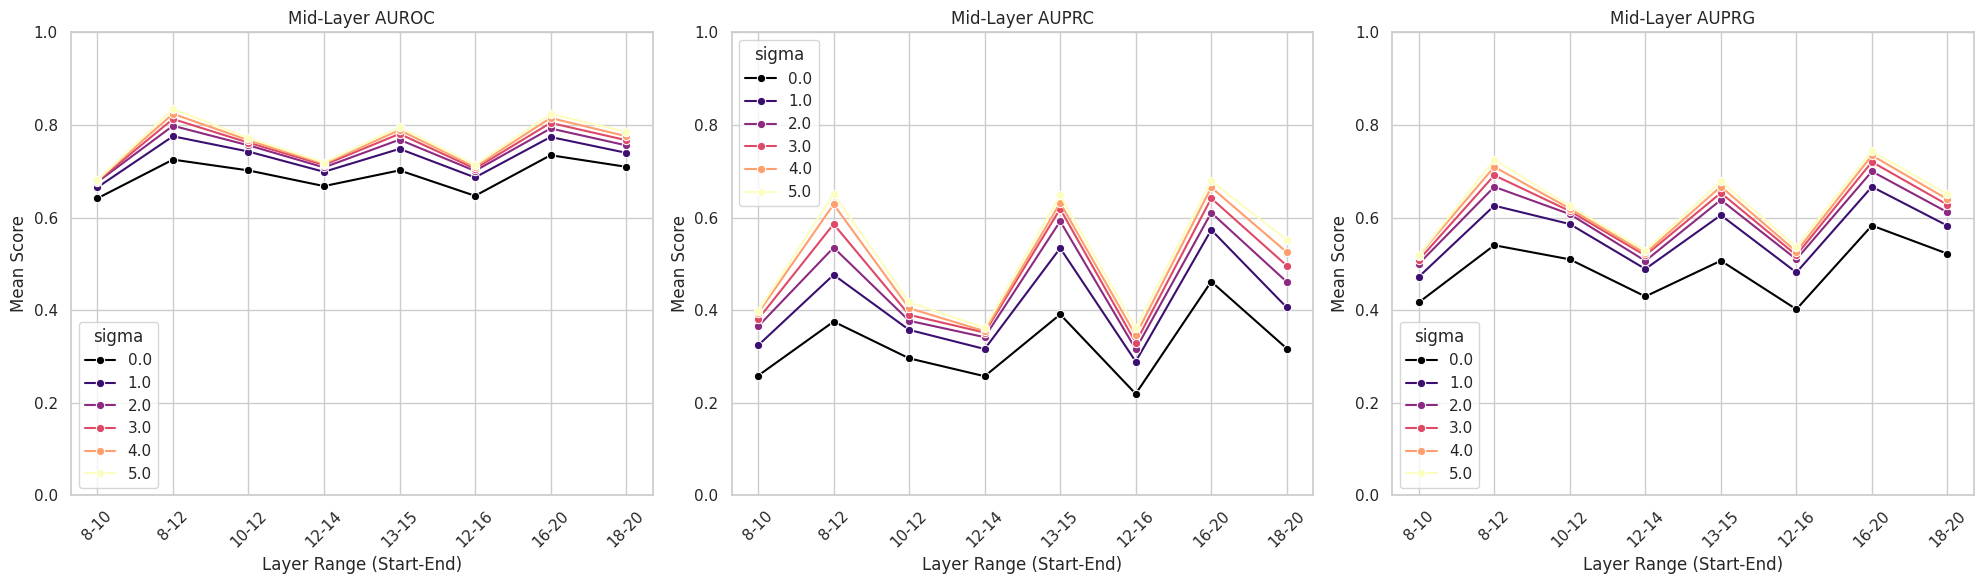

writing_attributions math


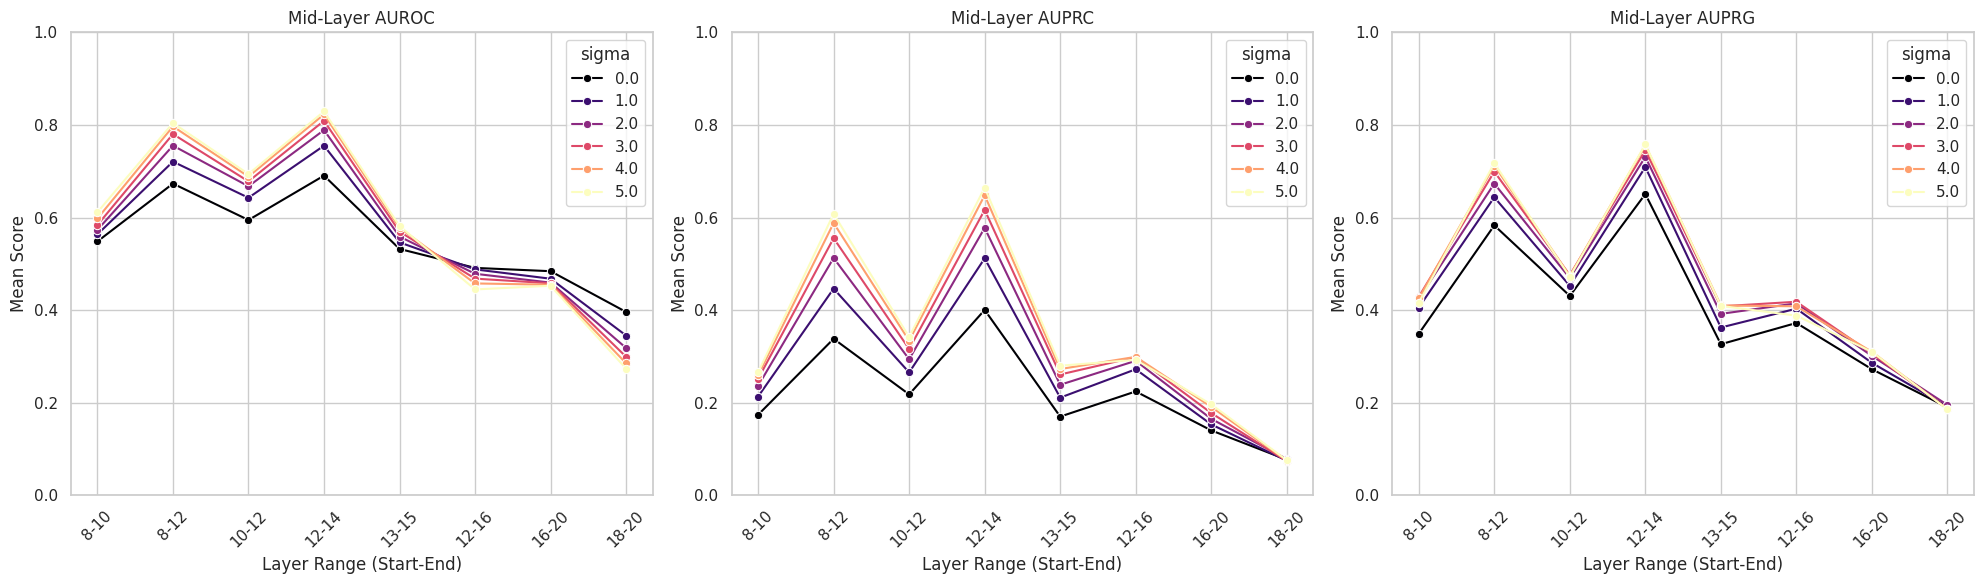

code_attributions writing


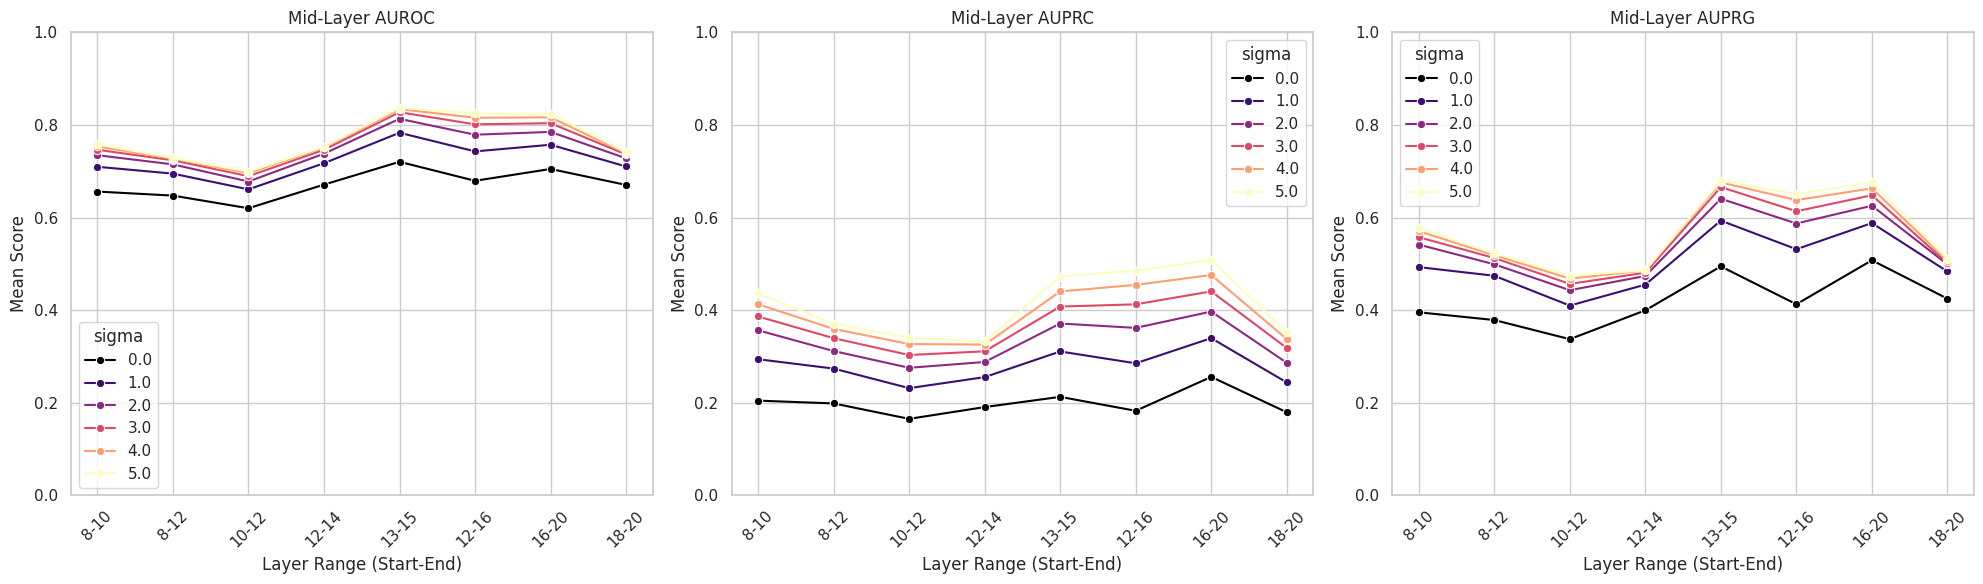

math_attributions writing


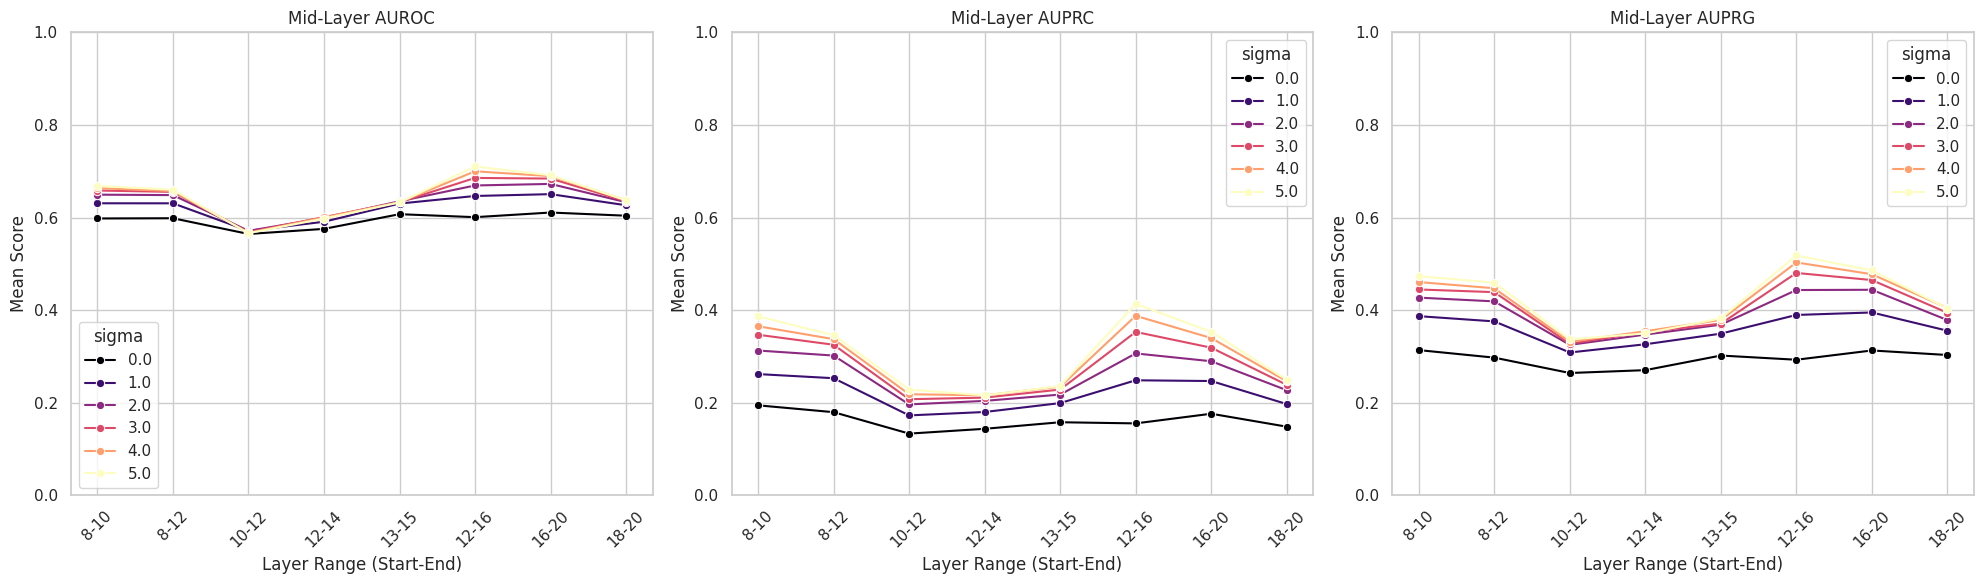

writing_attributions writing


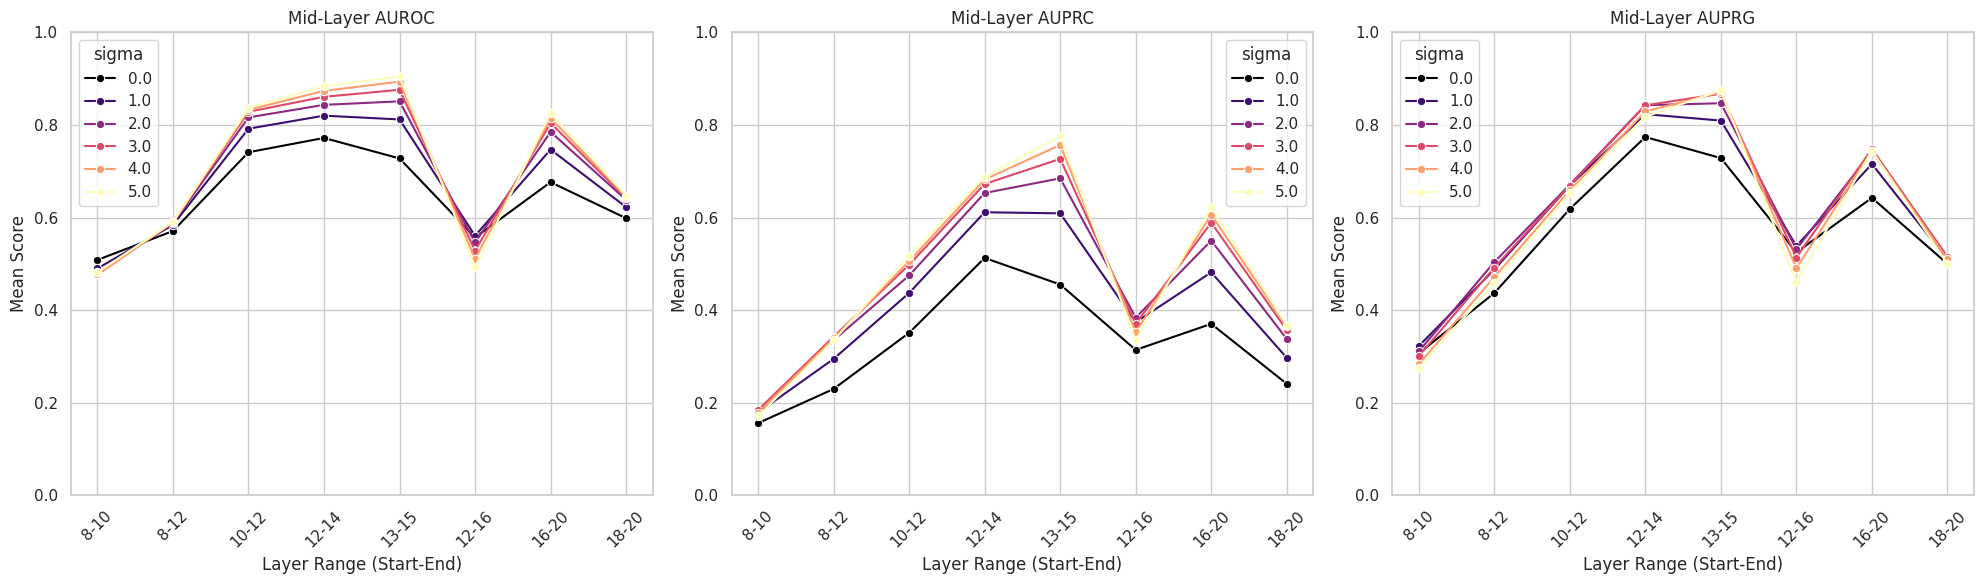

In [38]:
for probe_category in ['code', 'math', 'writing']:
    for save_dir in ['code_attributions', 'math_attributions', 'writing_attributions']:
        print(save_dir, probe_category)

        plot_prig_results(save_dir, probe_category)

code_attributions code ig


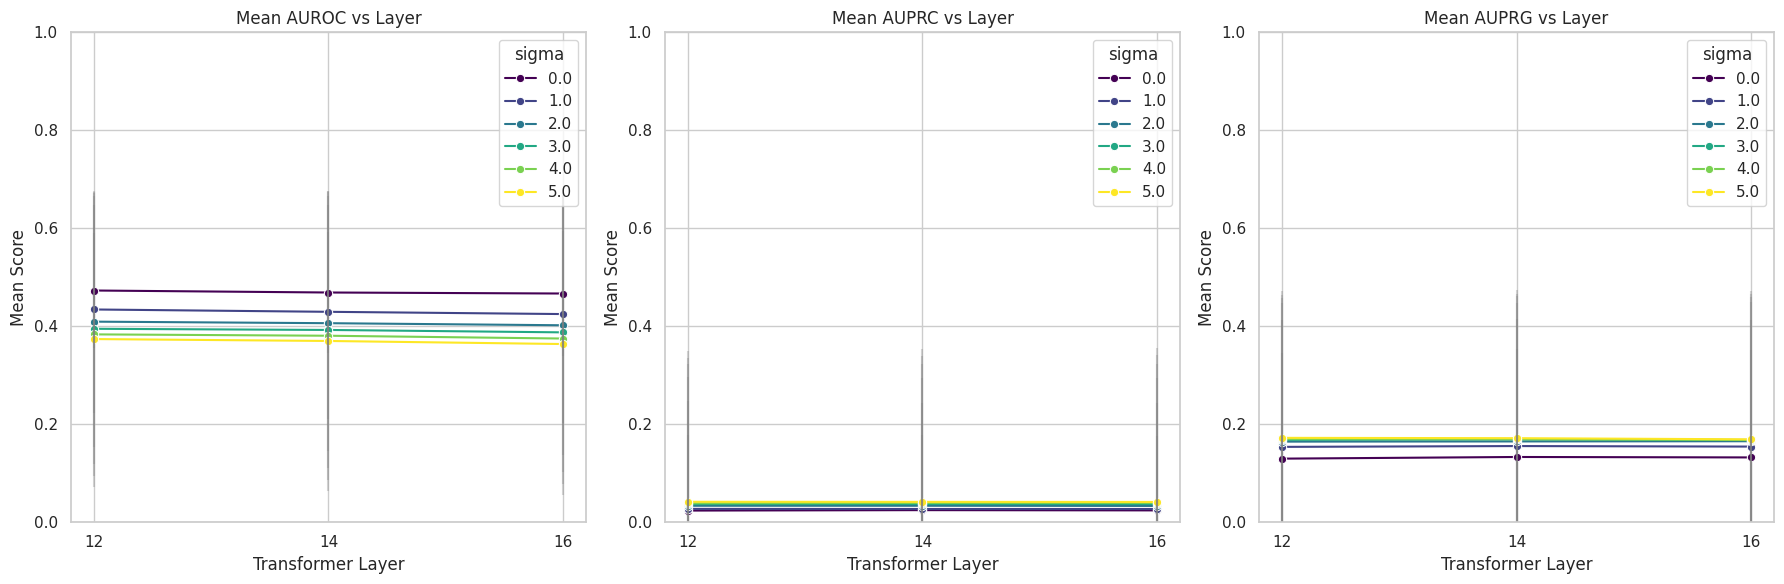

math_attributions math ig


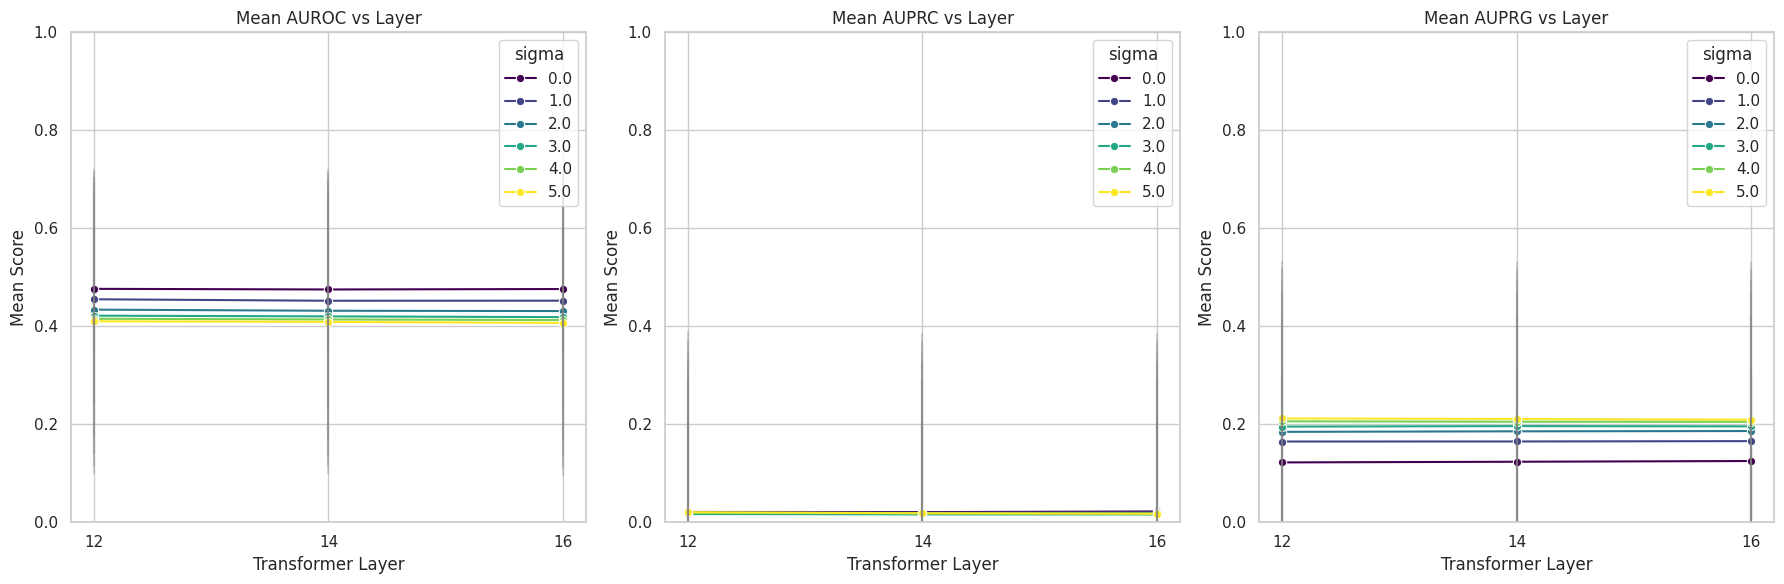

writing_attributions writing ig


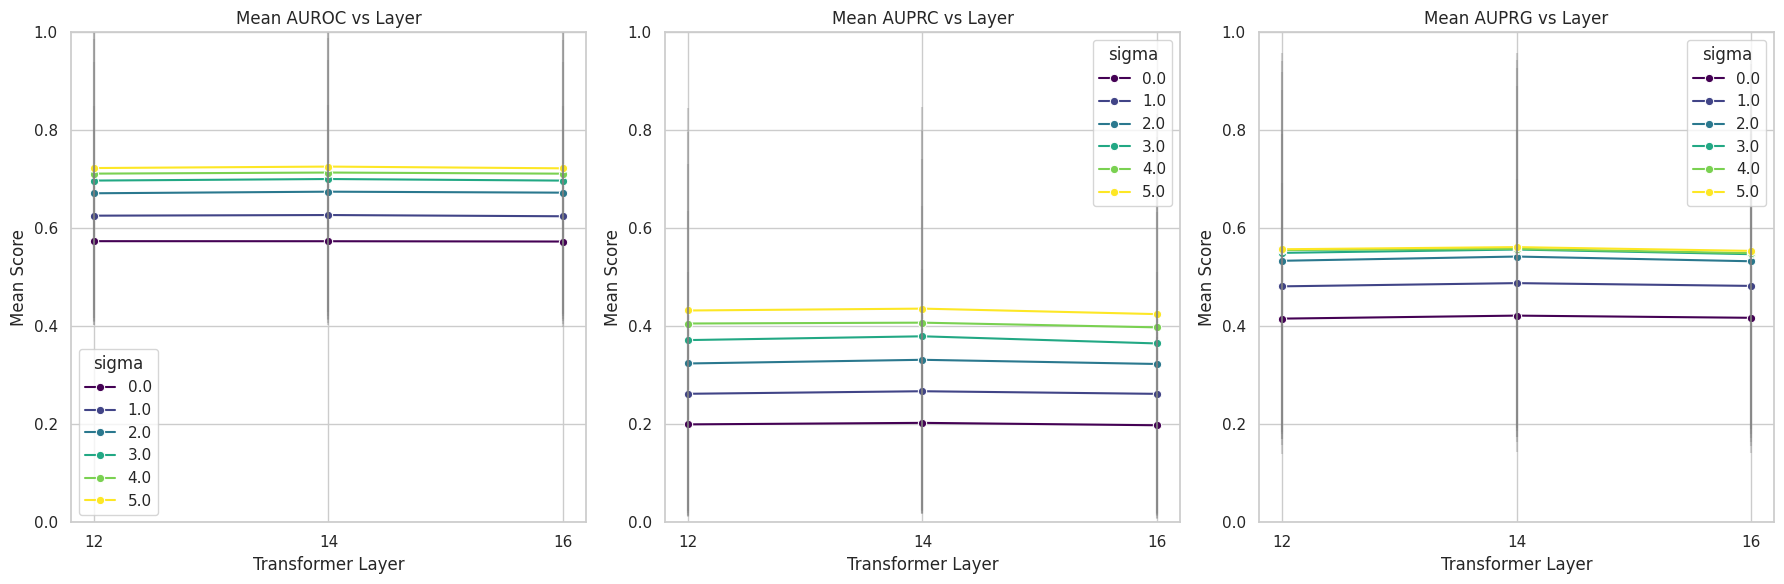

code_attributions code gradient


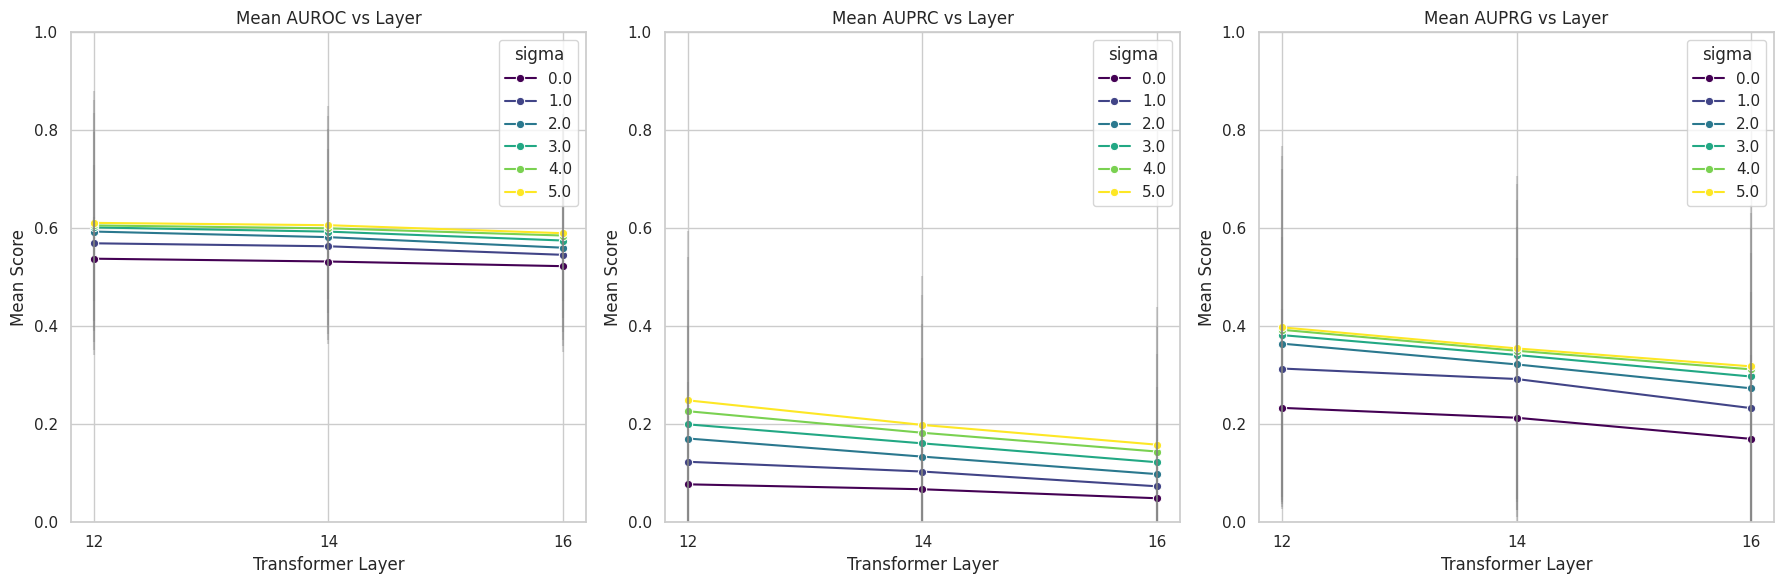

math_attributions math gradient


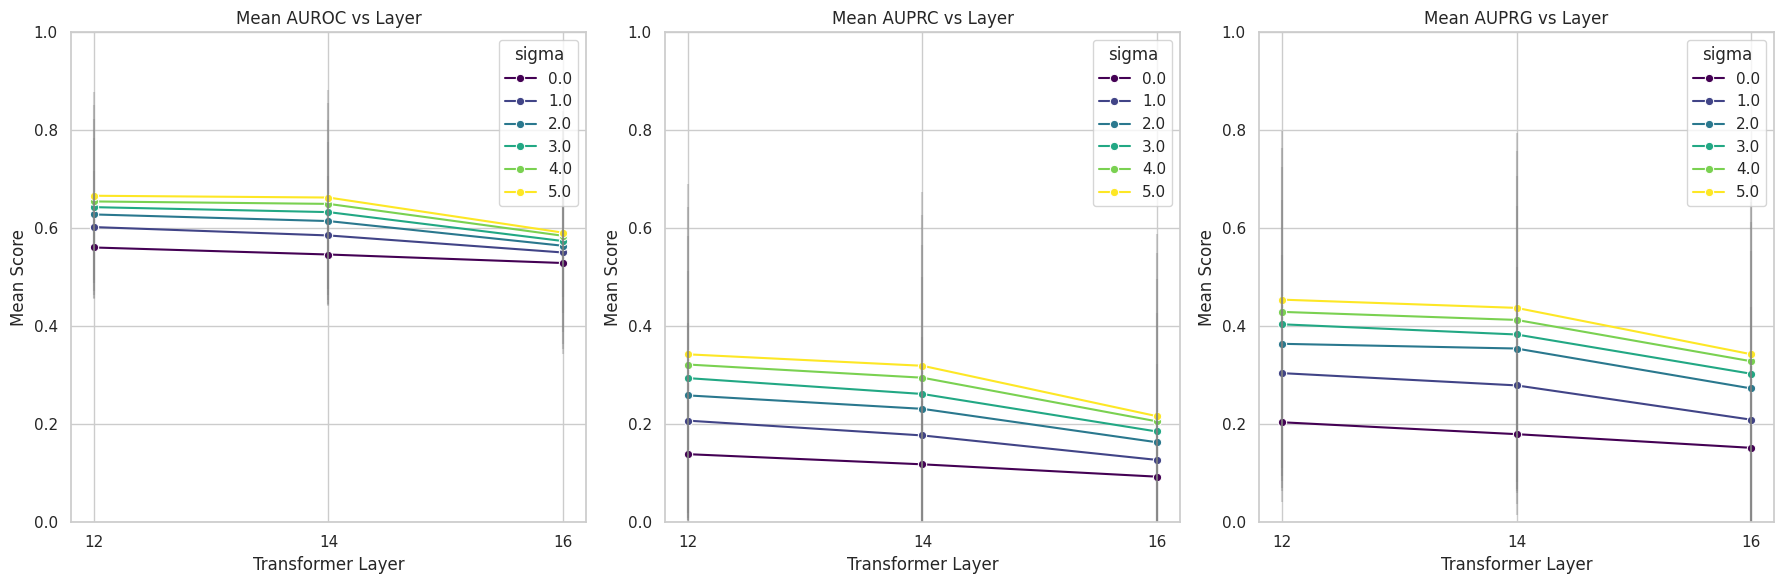

writing_attributions writing gradient


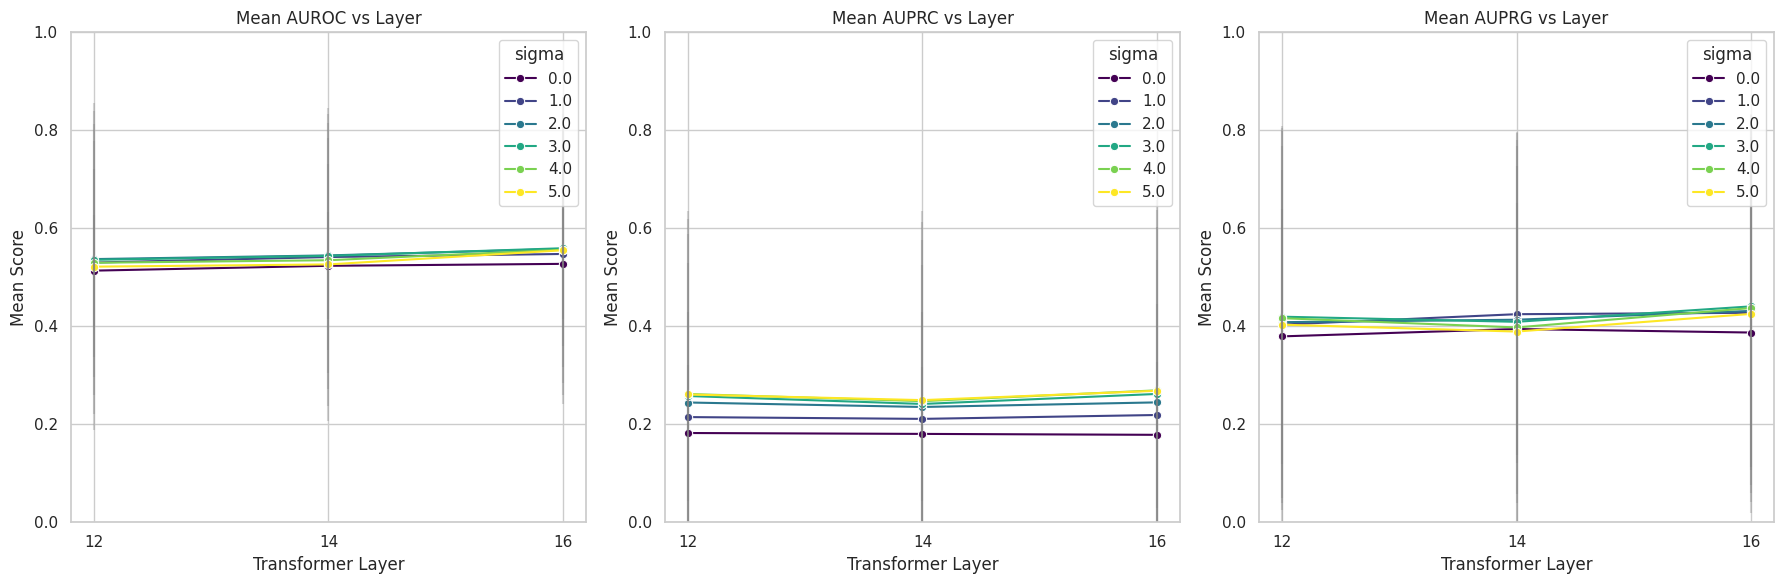

In [39]:
for method in ["ig", "gradient"]:
    for save_dir, probe_category in [('code_attributions', 'code'), ('math_attributions', 'math'), ('writing_attributions', 'writing')]:
        print(save_dir, probe_category, method)
        plot_scoring_results(save_dir, probe_category, method)

In [41]:
for method in ["gradient"]:
    for save_dir, probe_category in [('code_attributions', 'code'), ('math_attributions', 'math'), ('writing_attributions', 'writing')]:
        print(f"Probe: {probe_category}; Dataset evaluated on: {save_dir}")
        csv_file = f"{save_dir}/{probe_category}/{method}/results.csv"
        df = pd.read_csv(csv_file)
        # print(df.to_string(index=False))
        print("Best AUROC:")
        rocdf = df[(df['metric'] == 'auroc') & (df['sigma'].isin([3.0])) & (df['layer'] == 14)]
        print(rocdf.loc[rocdf['mean'].idxmax()].to_string())
        print("Best AUPRG:")
        prgdf = df[(df['metric'] == 'auprg') & (df['sigma'].isin([3.0]))& (df['layer'] == 14)]
        print(prgdf.loc[prgdf['mean'].idxmax()].to_string())
        print("=="*10)
        # plot_prig_results(save_dir, probe_category)

Probe: code; Dataset evaluated on: code_attributions
Best AUROC:
layer           14
metric       auroc
sigma          3.0
mean      0.593201
std       0.209374
Best AUPRG:
layer           14
metric       auprg
sigma          3.0
mean      0.341477
std       0.316749
Probe: math; Dataset evaluated on: math_attributions
Best AUROC:
layer           14
metric       auroc
sigma          3.0
mean      0.633054
std       0.187472
Best AUPRG:
layer           14
metric       auprg
sigma          3.0
mean      0.383258
std       0.324423
Probe: writing; Dataset evaluated on: writing_attributions
Best AUROC:
layer           14
metric       auroc
sigma          3.0
mean      0.543724
std        0.27133
Best AUPRG:
layer           14
metric       auprg
sigma          3.0
mean      0.409121
std       0.370614


In [128]:
# scores averaged over group of layers
scores = []
raw_attributions = []
for idx, data in results.items():

    attribution = np.zeros_like(data["attributions"]["0"])
    for layer in range(4,16):
        layer_attribution = np.array(data["attributions"][str(layer)])
        attribution += layer_attribution / np.linalg.norm(layer_attribution)

    mask = np.array(data["mask"])
    raw_attributions.append((attribution, mask))

    #If I randomly pick one token from inside the span and one from outside, 
    # what’s the probability the inside token gets a higher attribution score?
    attribution = gaussian_smooth(attribution, sigma=3)
    score = span_auroc(attribution, mask)

    
    # p = mask.sum() / len(mask)
    # score = (score -p) / (1-p)

    scores.append(score)

scores = np.array(scores)
# mean and std of scores
print(f"Mean score: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")

Mean score: 0.9539, Std: 0.0800


In [ ]:
# scores by layer
layers = list(range(model.cfg.n_layers)) #[12,14,16]#
scores_by_layer = [[] for _ in range(len(layers))]
for idx, data in results.items():
    for i, layer in enumerate(layers):
        attribution = np.array(data["attributions"][str(layer)])
        attribution = attribution / np.linalg.norm(attribution)
        score = span_auroc(attribution, data["mask"])
        scores_by_layer[i].append(score)

scores_by_layer = np.array(scores_by_layer)

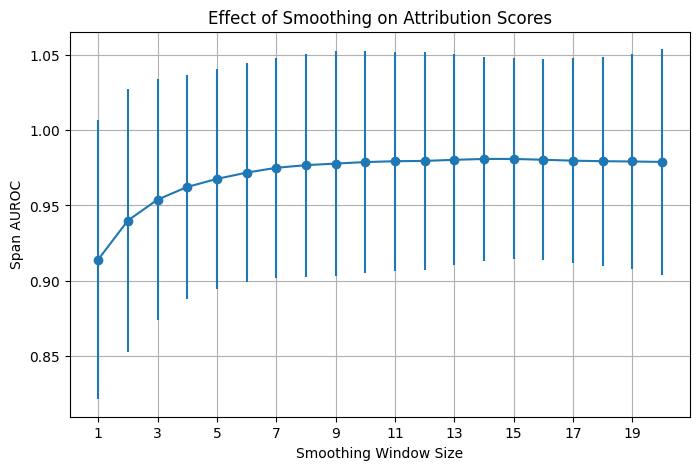

In [130]:
max_sm = 20
smoothed_scores = []
for sm in range(1, max_sm + 1):
    for a, mask in raw_attributions:
        # attribution = smooth_attribution(a, sm)
        attribution = gaussian_smooth(a, sigma=sm)
        smoothed_scores.append(span_auroc(attribution, mask))

    # mean and std of smoothed_scores for this smoothing window size
    # mean_score = np.mean(smoothed_scores)
    # std_score = np.std(smoothed_scores)
    # print(f"Smoothing window size: {sm}, Mean Span AUROC: {mean_score}, Std Span AUROC: {std_score}")

# plot the mean and std of smoothed_scores for each smoothing window size
smoothed_scores = np.array(smoothed_scores).reshape(max_sm, -1)
mean_scores = smoothed_scores.mean(axis=1)
std_scores = smoothed_scores.std(axis=1)
plt.figure(figsize=(8, 5))
plt.errorbar(range(1, max_sm + 1), mean_scores, yerr=std_scores, fmt='-o')
plt.xlabel('Smoothing Window Size')
plt.ylabel('Span AUROC')
plt.title('Effect of Smoothing on Attribution Scores')
plt.xticks(range(1, max_sm + 1, max(1, max_sm // 10)))
plt.grid()
plt.show()


In [184]:
for sm in range(1, 10):
    # smoothed = smooth_attribution(attribution, kernel_size=sm)
    smoothed = gaussian_smooth(attribution, sigma=sm)
    score = span_auroc(smoothed, data["mask"])
    print(f"Kernel size: {sm}, Span AUC: {score:.4f}")

Kernel size: 1, Span AUC: 0.8536
Kernel size: 2, Span AUC: 0.9046
Kernel size: 3, Span AUC: 0.9444
Kernel size: 4, Span AUC: 0.9686
Kernel size: 5, Span AUC: 0.9794
Kernel size: 6, Span AUC: 0.9780
Kernel size: 7, Span AUC: 0.9769
Kernel size: 8, Span AUC: 0.9769
Kernel size: 9, Span AUC: 0.9766


In [186]:
s = gaussian_smooth(attribution, sigma=3)
span_auc(s, data['mask'])

np.float64(0.9444444444444444)

In [ ]:
idx, data = list(results.items())[1]
# print(f"PID: {data['pid']}, Label: {data['label']}")
attribution = np.zeros_like(data["attributions"]["0"])
for layer in range(4,16):
    layer_attribution = np.array(data["attributions"][str(layer)])
    attribution += layer_attribution / np.linalg.norm(layer_attribution)

plot_heatmap(data["tokens"], attribution, title=None, mask=data["mask"],normalize=False)
plot_heatmap(data["tokens"], softmax(attribution), title=None, mask=data["mask"],normalize=False)
sigma = 1
s = gaussian_smooth(attribution, sigma=sigma)
plot_heatmap(data["tokens"], s, title=None, mask=data["mask"],normalize=False)
s = gaussian_smooth(softmax(attribution), sigma=sigma)
plot_heatmap(data["tokens"], s, title=None, mask=data["mask"],normalize=False)


In [ ]:
# plot boxplot of scores by layer
plt.figure(figsize=(12, 6))
sns.boxplot(data=scores_by_layer.T, )
plt.xlabel("Layer")
plt.ylabel("AUROC")
# limit y-axis to -0.1 to 0.1
plt.ylim(-.1, 1)
plt.title("Distribution of AUROC Scores by Layer")
plt.show()

# Pipelines

In [ ]:
# math probe for writing
random.seed(42)
dataset = []
for category in ['algebra', 'counting_and_probability', 'number_theory', 'geometry', 'intermediate_algebra', 'precalculus']:
    ds = load_dataset("EleutherAI/hendrycks_math", category)
    for item in ds['train']:
        dataset.append(item['problem'])
    for item in ds['test']:
        dataset.append(item['problem'])
print(f"Total problems in dataset: {len(dataset)}")
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4 and ('\n' not in p):
        filtered.append(p)

problems = [(i, p) for i, p in enumerate(filtered)]

print(f"Number of filtered problems: {len(problems)}")

# load ambiguous parts
dir_path = "math"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())
for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]
activations = {layer: [] for layer in range(model.cfg.n_layers)}
attn_activations = {layer: [] for layer in range(model.cfg.n_layers)}
    
for prompt in tqdm(formatted_questions, desc="Processing prompts"):
    # Tokenize the prompt
    tokens = model.to_tokens(prompt, prepend_bos=False)
    
    # Define the hooks to capture MLP post-activations
    hook_points = [f"blocks.{layer}.hook_resid_post" for layer in range(model.cfg.n_layers)]
    attn_points = [f"blocks.{layer}.attn.hook_z" for layer in range(model.cfg.n_layers)]
    
    # Run the model and cache the activations
    _, cache = model.run_with_cache(tokens, names_filter=lambda name: name in hook_points + attn_points)
    
    # For each layer, store the activation of the LAST token
    for layer in range(model.cfg.n_layers):
        # Shape of cache[hook_point] is (batch, seq_len, d_mlp)
        # We take the activation of the last token [-1] as the sequence representation
        last_token_activation = cache[hook_points[layer]][0, :, :].mean(dim=0).detach().cpu().numpy()
        activations[layer].append(last_token_activation)
        attn_activations[layer].append(cache[attn_points[layer]].detach().cpu().numpy())
        
# Convert lists of activations to numpy arrays
for layer in range(model.cfg.n_layers):
    activations[layer] = np.array(activations[layer])

random_state = 42     # 10 writing, 0 coding, 42 math
y = np.array(labels)
probe_accuracies = {}
probe_weights_by_layer = {}

for layer in tqdm(range(len(activations)), desc="Training Probes"):
    X = activations[layer]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )

    # Train a logistic regression probe
    probe = LogisticRegression(max_iter=5000, fit_intercept=False)
    probe.fit(X_train, y_train)
    
    # Evaluate the probe
    accuracy = probe.score(X_test, y_test)
    probe_accuracies[layer] = accuracy
    probe_weights_by_layer[layer] = probe.coef_

random.seed(42)
from collections import deque
dataset = []
cur_stems = deque([""]*5)
ds = load_dataset("PromptTensor/prompttensor-promptbank")
for item in tqdm(ds['train']):
    if item['intent'] in ['planning', 'generation']:
        if item['prompt_text'][:15] not in cur_stems:
            dataset.append(item['prompt_text'])
            cur_stems.append(item['prompt_text'][:15])
            cur_stems.popleft()
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4:
        filtered.append(p)

problems = [(i, p) for i, p in enumerate(filtered)]

# load ambiguous parts
dir_path = "writing"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())

for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]

random_state = 10     # 10 writing, 0 coding, 42 math
y = np.array(labels)

# get test sample indices
idxs = np.arange(len(labels))

train_idxs, test_idxs, _, _ = train_test_split(
    idxs, y, test_size=0.25, stratify=y, random_state=random_state
)

pairs = []
for pid, pdesc in problems:
    res = generate_mask(pid, pdesc)
    if res is not None:        
        pairs.append(res)

save_dir = "writing_attributions"
probe_category = "math"

method = "prig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

options = [(12,14), (10,12), (13,15), (12,16), (16,20), (8,10), (8,12), (18,20)]
for start_layer, end_layer in options:
    results = {}
    for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
        pid, pdesc = problems[idx]
        if pid not in unclear_sentences:
            continue
        prompt, _, mask = generate_mask(pid, pdesc)
        mask = mask[10:-5]
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_prig_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[idx] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
        }
        # Save intermediate results to file after each layer
        with open(f"{cur_dir}/prig_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

Total problems in dataset: 10424
Number of filtered problems: 357


357it [00:04, 83.21it/s]


Number of problems: 357
Combined dataset prepared with 714 total questions.
Final dataset prepared with 357 total questions.
Number of ambiguous questions: 194
Number of clear questions: 163


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7040/7040 [00:00<00:00, 13318.20it/s]
385it [00:04, 88.14it/s] 


Number of problems: 385
Combined dataset prepared with 770 total questions.
Final dataset prepared with 385 total questions.
Number of ambiguous questions: 210
Number of clear questions: 175


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97/97 [04:32<00:00,  2.81s/it]


In [34]:
# writing probe for math and for code
random.seed(42)
from collections import deque
dataset = []
cur_stems = deque([""]*5)
ds = load_dataset("PromptTensor/prompttensor-promptbank")
for item in tqdm(ds['train']):
    if item['intent'] in ['planning', 'generation']:
        if item['prompt_text'][:15] not in cur_stems:
            dataset.append(item['prompt_text'])
            cur_stems.append(item['prompt_text'][:15])
            cur_stems.popleft()
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4:
        filtered.append(p)

problems = [(i, p) for i, p in enumerate(filtered)]

# load ambiguous parts
dir_path = "writing"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())

for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]

activations = {layer: [] for layer in range(model.cfg.n_layers)}
attn_activations = {layer: [] for layer in range(model.cfg.n_layers)}
    
for prompt in tqdm(formatted_questions, desc="Processing prompts"):
    # Tokenize the prompt
    tokens = model.to_tokens(prompt, prepend_bos=False)
    
    # Define the hooks to capture MLP post-activations
    hook_points = [f"blocks.{layer}.hook_resid_post" for layer in range(model.cfg.n_layers)]
    attn_points = [f"blocks.{layer}.attn.hook_z" for layer in range(model.cfg.n_layers)]
    
    # Run the model and cache the activations
    _, cache = model.run_with_cache(tokens, names_filter=lambda name: name in hook_points + attn_points)
    
    # For each layer, store the activation of the LAST token
    for layer in range(model.cfg.n_layers):
        # Shape of cache[hook_point] is (batch, seq_len, d_mlp)
        # We take the activation of the last token [-1] as the sequence representation
        last_token_activation = cache[hook_points[layer]][0, :, :].mean(dim=0).detach().cpu().numpy()
        activations[layer].append(last_token_activation)
        attn_activations[layer].append(cache[attn_points[layer]].detach().cpu().numpy())
        
# Convert lists of activations to numpy arrays
for layer in range(model.cfg.n_layers):
    activations[layer] = np.array(activations[layer])

random_state = 10     # 10 writing, 0 coding, 42 math
y = np.array(labels)
probe_accuracies = {}
probe_weights_by_layer = {}

for layer in tqdm(range(len(activations)), desc="Training Probes"):
    X = activations[layer]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )

    # Train a logistic regression probe
    probe = LogisticRegression(max_iter=5000, fit_intercept=False)
    probe.fit(X_train, y_train)
    
    # Evaluate the probe
    accuracy = probe.score(X_test, y_test)
    probe_accuracies[layer] = accuracy
    probe_weights_by_layer[layer] = probe.coef_

random.seed(42)
# load original problems
ds = load_dataset('newfacade/LeetCodeDataset', trust_remote_code=True)
hard_problems = [example for example in ds['train'] if example['difficulty'] == 'Hard']
print(f'Number of hard problems: {len(hard_problems)}')
problems = [(p['question_id'], p['problem_description'].split('\n\xa0')[0].replace('\xa0', " ")) for p in hard_problems 
            if len(p['problem_description'].split('\n\xa0')[0].split('.')) >= 5]
print(f'Number of hard problems with at least 5 sentences: {len(problems)}')

# load ambiguous parts
dir_path = "leetcode/unclear_portion"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())

for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]

random_state = 0     # 10 writing, 0 coding, 42 math
y = np.array(labels)
# get test sample indices
idxs = np.arange(len(labels))

train_idxs, test_idxs, _, _ = train_test_split(
    idxs, y, test_size=0.25, stratify=y, random_state=random_state
)
pairs = []
for pid, pdesc in problems:
    res = generate_mask(pid, pdesc)
    if res is not None:        
        pairs.append(res)

save_dir = "code_attributions"
probe_category = "writing"

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7040/7040 [00:00<00:00, 13758.43it/s]
385it [00:00, 3096.42it/s]


Number of problems: 385
Combined dataset prepared with 770 total questions.
Final dataset prepared with 385 total questions.
Number of ambiguous questions: 210
Number of clear questions: 175


Training Probes: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:37<00:00,  1.16s/it]


Number of hard problems: 606
Number of hard problems with at least 5 sentences: 501


501it [00:00, 2596.48it/s]

Number of problems: 501
Combined dataset prepared with 981 total questions.
Final dataset prepared with 501 total questions.
Number of ambiguous questions: 265
Number of clear questions: 236


In [35]:
method = "prig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

options = [(12,14), (10,12), (13,15), (12,16), (16,20), (8,10), (8,12), (18,20)]
for start_layer, end_layer in options:
    results = {}
    for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
        pid, pdesc = problems[idx]
        if pid not in unclear_sentences:
            continue
        prompt, _, mask = generate_mask(pid, pdesc)
        mask = mask[10:-5]
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_prig_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[idx] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
        }
        # Save intermediate results to file after each layer
        with open(f"{cur_dir}/prig_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

random.seed(42)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 126/126 [05:55<00:00,  2.82s/it]


In [36]:
dataset = []
for category in ['algebra', 'counting_and_probability', 'number_theory', 'geometry', 'intermediate_algebra', 'precalculus']:
    ds = load_dataset("EleutherAI/hendrycks_math", category)
    for item in ds['train']:
        dataset.append(item['problem'])
    for item in ds['test']:
        dataset.append(item['problem'])
print(f"Total problems in dataset: {len(dataset)}")
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4 and ('\n' not in p):
        filtered.append(p)

problems = [(i, p) for i, p in enumerate(filtered)]

print(f"Number of filtered problems: {len(problems)}")

# load ambiguous parts
dir_path = "math"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())

for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]

random_state = 42     # 10 writing, 0 coding, 42 math
y = np.array(labels)

# get test sample indices
idxs = np.arange(len(labels))

train_idxs, test_idxs, _, _ = train_test_split(
    idxs, y, test_size=0.25, stratify=y, random_state=random_state
)

pairs = []
for pid, pdesc in problems:
    res = generate_mask(pid, pdesc)
    if res is not None:        
        pairs.append(res)
save_dir = "math_attributions"
probe_category = "writing"

method = "prig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

options = [(12,14), (10,12), (13,15), (12,16), (16,20), (8,10), (8,12), (18,20)]
for start_layer, end_layer in options:
    results = {}
    for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
        pid, pdesc = problems[idx]
        if pid not in unclear_sentences:
            continue
        prompt, _, mask = generate_mask(pid, pdesc)
        mask = mask[10:-5]
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_prig_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[idx] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
        }
        # Save intermediate results to file after each layer
        with open(f"{cur_dir}/prig_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

Total problems in dataset: 10424
Number of filtered problems: 357


357it [00:05, 67.07it/s]


Number of problems: 357
Combined dataset prepared with 714 total questions.
Final dataset prepared with 357 total questions.
Number of ambiguous questions: 194
Number of clear questions: 163


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [04:06<00:00,  2.73s/it]


In [37]:
random.seed(42)
from collections import deque
dataset = []
cur_stems = deque([""]*5)
ds = load_dataset("PromptTensor/prompttensor-promptbank")
for item in tqdm(ds['train']):
    if item['intent'] in ['planning', 'generation']:
        if item['prompt_text'][:15] not in cur_stems:
            dataset.append(item['prompt_text'])
            cur_stems.append(item['prompt_text'][:15])
            cur_stems.popleft()
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4:
        filtered.append(p)

problems = [(i, p) for i, p in enumerate(filtered)]

# load ambiguous parts
dir_path = "writing"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())
for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

# format questions with chat template
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

formatted_questions = [format_question(q) for q in questions]

random_state = 10     # 10 writing, 0 coding, 42 math
y = np.array(labels)

# get test sample indices
idxs = np.arange(len(labels))

train_idxs, test_idxs, _, _ = train_test_split(
    idxs, y, test_size=0.25, stratify=y, random_state=random_state
)


pairs = []
for pid, pdesc in problems:
    res = generate_mask(pid, pdesc)
    if res is not None:        
        pairs.append(res)

save_dir = "writing_attributions"
probe_category = "writing"

method = "prig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

options = [(12,14), (10,12), (13,15), (12,16), (16,20), (8,10), (8,12), (18,20)]
for start_layer, end_layer in options:
    results = {}
    for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
        pid, pdesc = problems[idx]
        if pid not in unclear_sentences:
            continue
        prompt, _, mask = generate_mask(pid, pdesc)
        mask = mask[10:-5]
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_prig_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[idx] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
        }
        # Save intermediate results to file after each layer
        with open(f"{cur_dir}/prig_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7040/7040 [00:00<00:00, 14040.36it/s]
385it [00:01, 323.00it/s]


Number of problems: 385
Combined dataset prepared with 770 total questions.
Final dataset prepared with 385 total questions.
Number of ambiguous questions: 210
Number of clear questions: 175


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97/97 [04:33<00:00,  2.82s/it]


In [38]:
method = "gradient"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)

results = {}
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    prompt, _, mask = generate_mask(pid, pdesc)
    mask = mask[10:-5]
    
    attributions = {}
    for layer in [12, 14, 16]:#range(model.cfg.n_layers):
        probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
        # str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
        str_tokens, scores = get_ambiguity_attribution(model, prompt, layer, probe_weights, verbose=False)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions[layer] = scores.tolist()
    
    results[idx] = {
        "pid": pid,
        "pdesc": pdesc,
        "tokens": str_tokens,
        "attributions": attributions,
        "mask": mask.tolist(),
    }
    # Save intermediate results to file after each layer
    with open(f"{cur_dir}/attribution_results.json", "w") as f:
        json.dump(results, f)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97/97 [00:47<00:00,  2.03it/s]


In [ ]:
method = "ig"
cur_dir = f"{save_dir}/{probe_category}/{method}/"
os.makedirs(cur_dir, exist_ok=True)
results = {}
with open(f"{save_dir}/{probe_category}/{method}/attribution_results.json", "r") as f:
    results = json.load(f)
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    prompt, _, mask = generate_mask(pid, pdesc)
    mask = mask[10:-5]
    
    attributions = {}
    for layer in [12, 14, 16]: 
        probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, baseline=baseline_token, verbose=False)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions[layer] = scores.tolist()
    
    results[idx] = {
        "pid": pid,
        "pdesc": pdesc,
        "tokens": str_tokens,
        "attributions": attributions,
        "mask": mask.tolist(),
    }
    # Save intermediate results to file after each layer
    with open(f"{cur_dir}/attribution_results.json", "w") as f:
        json.dump(results, f)

 84%|█████████████████████████████████████████████████████████████████████████████████████████████████████▉                    | 81/97 [24:22<04:49, 18.08s/it]